In [1]:
# AudDSR Paper-Aligned Implementation
# ====================================
# Two-stage training pipeline:
# Stage 1: Discrete VQ-VAE autoencoder on all machine types (general feature space)
# Stage 2: Anomaly detector + object-specific decoder on all machine types
#
# This notebook implements the exact architecture and training flow from the AudDSR paper.

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset

In [ ]:
# -----------------------------
# Experiment options
# TUNING FOR CROSS-MACHINE GENERALIZATION
# Current issue: slider (0.4979) and gearbox (0.5064) underperform
# Strategy: Increase capacity + adjust loss weighting
# MAIN PITFALL: Detector collapses because synthetic anomalies are too easy
# FIX: Progressively harden anomalies during Stage 2
# -----------------------------

# Quick test mode: reduce training time for fast iteration (set to False for full training)
QUIK_MODE = True  # Requested mode switch
QUICK_TEST_MODE = QUIK_MODE  # Set to False for full 5-epoch training

if QUICK_TEST_MODE:
    print("⚡ QUICK TEST MODE ENABLED (15 min training)")
    STAGE1_EPOCHS = 2
    STAGE2_EPOCHS = 2
else:
    STAGE1_EPOCHS = 5
    STAGE2_EPOCHS = 5

# Stage 1 temperature annealing.
STAGE1_TEMP_MODE = "linear"
STAGE1_TEMP_START = 1.8
STAGE1_TEMP_END = 0.8

# (4) Quantizer capacity options.
QUANTIZER_OPTIONS = {
    "tiny":   {"q1_embeddings": 128,  "q2_embeddings": 128},
    "small":  {"q1_embeddings": 256,  "q2_embeddings": 256},
    "base":   {"q1_embeddings": 512,  "q2_embeddings": 512},
    "large":  {"q1_embeddings": 1024, "q2_embeddings": 1024},
    "xlarge": {"q1_embeddings": 2048, "q2_embeddings": 2048},
}
SELECTED_QUANTIZER = "large"  # UP from "base" to learn richer discrete features

# (6) Frontend options from the paper setup family.
FRONTEND_OPTIONS = {
    "transient": {"n_fft": 512,  "hop_length": 128, "n_mels": 128, "norm": "per_bin"},
    "balanced":  {"n_fft": 1024, "hop_length": 256, "n_mels": 128, "norm": "per_bin"},
    "harmonic":  {"n_fft": 2048, "hop_length": 512, "n_mels": 128, "norm": "global"},
    "low_compute": {"n_fft": 512, "hop_length": 256, "n_mels": 64, "norm": "none"},
}
SELECTED_FRONTEND = "balanced"

# (3.3) Anomaly mask generation processes.
# - perlin_like: smooth random map thresholding
# - band_time: random frequency band + several time segments (closest to the paper's dedicated audio mask process)
# - mixed_structured: samples a family of mask shapes to mimic varied latent faults
CORRUPTION_OPTIONS = {
    "perlin_like": {
        "mode": "perlin_like",
        "ratio": 0.18,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "random_code",
        "mix_alpha": 0.75,
        "mask_dilation": 0,
    },
    "band_time": {
        "mode": "band_time",
        "ratio": 0.28,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix+random",
        "mix_alpha": 0.70,
        "mask_dilation": 1,
    },
    "mixed_structured": {
        "mode": "mixed_structured",
        "ratio": 0.28,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix+random",
        "mix_alpha": 0.65,
        "mask_dilation": 2,
    },
    "point": {
        "mode": "point",
        "ratio": 0.20,
        "block_hw": (4, 4),
        "low_res": (8, 8),
        "replace_strategy": "random_code",
        "mix_alpha": 0.75,
        "mask_dilation": 0,
    },
    "time_stripe": {
        "mode": "time_stripe",
        "ratio": 0.20,
        "block_hw": (4, 16),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix",
        "mix_alpha": 0.75,
        "mask_dilation": 1,
    },
    "freq_stripe": {
        "mode": "freq_stripe",
        "ratio": 0.20,
        "block_hw": (16, 4),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix",
        "mix_alpha": 0.75,
        "mask_dilation": 1,
    },
    "block_medium": {
        "mode": "block",
        "ratio": 0.20,
        "block_hw": (8, 8),
        "low_res": (8, 8),
        "replace_strategy": "batch_mix",
        "mix_alpha": 0.75,
        "mask_dilation": 1,
    },
}
SELECTED_CORRUPTION = "mixed_structured"

# (5) Detector width options. Paper detector input is concat(XG, XS).
DETECTOR_OPTIONS = {
    "light": {"width": 32},
    "wide": {"width": 64},
}
SELECTED_DETECTOR = "wide"

# Paths and runtime settings
DATA_ROOT = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
ALL_MACHINE_TYPES = ["bearing", "fan", "gearbox", "slider", "ToyCar", "ToyTrain", "valve"]

# Paper-mimic split strategy:
# - Stage 1 learns a general discrete latent space from all machine types.
# - Stage 2 is also trained/evaluated on ALL machine types (multi-machine anomaly detection).
STAGE1_MACHINE_TYPES = ALL_MACHINE_TYPES
STAGE2_MACHINE_TYPES = ALL_MACHINE_TYPES

TARGET_SR = 16_000
SPEC_SIZE = 128
BATCH_SIZE = 8
VISUALIZE_INDEX = 0
TOPK_RATIO = 0.05

# Score blending and calibration.
MAP_SCORE_WEIGHT = 0.00
REC_SCORE_WEIGHT = 1.00
AUDIT_REC_WEIGHT = 0.85
AUDIT_MAP_WEIGHT = 0.15
MAP_GAP_BLEND_THRESHOLD = 0.02
CALIBRATION_FILES_PER_MACHINE = 25
CALIBRATION_QUANTILE = 0.99
STAGE1_CODEBOOK_USAGE_WEIGHT = 0.20
STAGE1_USAGE_EPS = 1e-6
VQ_TEMPERATURE = STAGE1_TEMP_START

# Training/data budget.
# In quick mode, keep this small so the notebook can be rerun end-to-end.
if QUICK_TEST_MODE:
    SUBSET_TRAIN_PER_MACHINE = 20
    SUBSET_TEST_PER_MACHINE = 20
else:
    SUBSET_TRAIN_PER_MACHINE = 0
    SUBSET_TEST_PER_MACHINE = 100
SUBSET_SEED = 42

# Ensure this section can run independently.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1 (discrete autoencoder) paper-like defaults, increased runtime budget.
LR_STAGE1 = 2e-4
LAMBDA_X = 1.0
LAMBDA_K = 0.25

# Stage 2 settings: keep both clean/anomalous samples so detector sees both classes.
# IMPROVEMENT: Enable progressive corruption hardening to prevent detector collapse
LR_STAGE2 = 2e-4
STAGE2_ANOMALY_BATCH_RATIO = 0.5
LAMBDA_STAGE2_REC = 1.0
LAMBDA_STAGE2_DET = 5.0
FOCAL_ALPHA = 0.60
FOCAL_GAMMA = 1.0
DET_POS_WEIGHT = 4.0

# HARDENED CORRUPTION: Progressive difficulty during Stage 2 training
ENABLE_PROGRESSIVE_CORRUPTION = True  # When True, corruption difficulty increases each epoch
if ENABLE_PROGRESSIVE_CORRUPTION:
    CORRUPTION_RATIO_SCHEDULE = [0.25, 0.30, 0.35, 0.40, 0.45]  # Epoch-wise ratios
else:
    CORRUPTION_RATIO_SCHEDULE = [0.35] * STAGE2_EPOCHS  # Constant ratio

q_cfg = QUANTIZER_OPTIONS[SELECTED_QUANTIZER]
f_cfg = FRONTEND_OPTIONS[SELECTED_FRONTEND]
c_cfg = CORRUPTION_OPTIONS[SELECTED_CORRUPTION]
d_cfg = DETECTOR_OPTIONS[SELECTED_DETECTOR]

print("Selected options:")
print(f"- device:                   {device}")
print(f"- quantizer:                {SELECTED_QUANTIZER} -> {q_cfg}")
print(f"- frontend:                 {SELECTED_FRONTEND} -> {f_cfg}")
print(f"- corruption:               {SELECTED_CORRUPTION} -> {c_cfg}")
print(f"- detector:                 {SELECTED_DETECTOR} -> {d_cfg}")
print(f"- stage1 machines:          {STAGE1_MACHINE_TYPES}")
print(f"- stage2 machines:          {STAGE2_MACHINE_TYPES}")
print(f"- stage1 epochs/lr:         {STAGE1_EPOCHS} / {LR_STAGE1}")
print(f"- stage2 epochs/lr:         {STAGE2_EPOCHS} / {LR_STAGE2}")
print(f"- detector weight:          {LAMBDA_STAGE2_DET}")
print(f"- stage2 anomaly fraction:  {STAGE2_ANOMALY_BATCH_RATIO}")
print(f"- focal alpha/gamma:        {FOCAL_ALPHA} / {FOCAL_GAMMA}")
print(f"- detector pos weight:      {DET_POS_WEIGHT}")
print(f"- map/rec score weights:    {MAP_SCORE_WEIGHT} / {REC_SCORE_WEIGHT}")
print(f"- audit rec/map weights:    {AUDIT_REC_WEIGHT} / {AUDIT_MAP_WEIGHT}")
print(f"- map gap blend threshold:  {MAP_GAP_BLEND_THRESHOLD}")
print(f"- calibration files/machine: {CALIBRATION_FILES_PER_MACHINE}")
print(f"- calibration quantile:     {CALIBRATION_QUANTILE}")
print(f"- subset train per machine: {SUBSET_TRAIN_PER_MACHINE}")
print(f"- subset test per machine:  {SUBSET_TEST_PER_MACHINE}")
print(f"- progressive corruption:   {ENABLE_PROGRESSIVE_CORRUPTION}")
if ENABLE_PROGRESSIVE_CORRUPTION:
    print(f"- corruption ratio schedule: {CORRUPTION_RATIO_SCHEDULE[:STAGE2_EPOCHS]}")
print()
print("IMPROVEMENT: Stronger structured corruption, calibration thresholding, and controlled detector blending")
print("Expected: More realistic latent anomalies and clearer sample-level decisions")

⚡ QUICK TEST MODE ENABLED (15 min training)
Selected options:
- device:                   cpu
- quantizer:                large -> {'q1_embeddings': 1024, 'q2_embeddings': 1024}
- frontend:                 balanced -> {'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'norm': 'per_bin'}
- corruption:               mixed_structured -> {'mode': 'mixed_structured', 'ratio': 0.28, 'block_hw': (8, 8), 'low_res': (8, 8), 'replace_strategy': 'batch_mix+random', 'mix_alpha': 0.65, 'mask_dilation': 2}
- detector:                 wide -> {'width': 64}
- stage1 machines:          ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
- stage2 machines:          ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
- stage1 epochs/lr:         2 / 0.0002
- stage2 epochs/lr:         2 / 0.0002
- detector weight:          5.0
- stage2 anomaly fraction:  0.5
- focal alpha/gamma:        0.6 / 1.0
- detector pos weight:      4.0
- map/rec score weights:    0.0 / 1.0
- aud

## Shared Helpers
Reusable file loading, spectrogram, model, and loss helpers used by the rest of the notebook.

In [15]:
import os

import numpy as np
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile
from torch.utils.data import Dataset


def collect_wav_files(folder):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
    return sorted(wav_paths)


def collect_machine_split_files(data_root, machine_type, split):
    split_dir = os.path.join(data_root, f"dev_{machine_type}", machine_type, split)
    return collect_wav_files(split_dir)


def collect_multi_machine_split_files(data_root, machine_types, split):
    files = []
    for machine in machine_types:
        files.extend(collect_machine_split_files(data_root, machine, split))
    return sorted(files)


def collect_multi_machine_split_files_limited(
    data_root,
    machine_types,
    split,
    max_per_machine=0,
    seed=0,
):
    if max_per_machine <= 0:
        return collect_multi_machine_split_files(data_root, machine_types, split)

    files = []
    for machine in machine_types:
        machine_files = collect_machine_split_files(data_root, machine, split)
        rng = np.random.default_rng(seed + abs(hash((machine, split))) % 1_000_000)
        if len(machine_files) > max_per_machine:
            idx = rng.choice(len(machine_files), size=max_per_machine, replace=False)
            machine_files = [machine_files[i] for i in sorted(idx.tolist())]
        files.extend(machine_files)
    return sorted(files)


def infer_machine_type_from_path(path):
    path_lower = path.replace("\\", "/").lower()
    for machine in ALL_MACHINE_TYPES:
        token = f"/dev_{machine.lower()}/"
        if token in path_lower:
            return machine
    return "unknown"


def load_waveform(path, target_sr=TARGET_SR):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0)


def normalize_spec(spec, mode):
    if mode == "none":
        return spec
    if mode == "global":
        mean = spec.mean()
        std = spec.std().clamp_min(1e-6)
        return (spec - mean) / std
    if mode == "per_bin":
        mean = spec.mean(dim=-1, keepdim=True)
        std = spec.std(dim=-1, keepdim=True).clamp_min(1e-6)
        return (spec - mean) / std
    raise ValueError(f"Unknown normalization mode: {mode}")


def build_mel_transform(frontend_cfg):
    return T.MelSpectrogram(
        sample_rate=TARGET_SR,
        n_fft=frontend_cfg["n_fft"],
        hop_length=frontend_cfg["hop_length"],
        n_mels=frontend_cfg["n_mels"],
    )


def waveform_to_model_input(waveform, mel_transform, frontend_cfg):
    spec = torch.log1p(mel_transform(waveform)).unsqueeze(0)
    spec = normalize_spec(spec, frontend_cfg["norm"])
    spec = F.interpolate(
        spec.unsqueeze(0),
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)
    return spec


class SpectrogramFileDataset(Dataset):
    def __init__(self, file_paths, mel_transform, frontend_cfg):
        self.file_paths = file_paths
        self.mel_transform = mel_transform
        self.frontend_cfg = frontend_cfg

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform = load_waveform(file_path)
        spec = waveform_to_model_input(waveform, self.mel_transform, self.frontend_cfg)
        return spec, file_path


def quantizer_usage_stats(indices, num_embeddings):
    flat = indices.reshape(-1).detach()
    counts = torch.bincount(flat, minlength=num_embeddings).float()
    total = counts.sum().clamp_min(1.0)
    probs = counts / total
    nonzero = probs > 0
    entropy = -(probs[nonzero] * torch.log(probs[nonzero])).sum() if nonzero.any() else torch.tensor(0.0, device=counts.device)
    perplexity = torch.exp(entropy)
    usage = (counts > 0).float().mean()
    return float(usage.item()), float(perplexity.item())


def dilate_mask(mask, radius=1):
    if radius <= 0:
        return mask.bool()
    kernel_size = 2 * radius + 1
    return F.max_pool2d(mask.float(), kernel_size=kernel_size, stride=1, padding=radius).bool()


def make_corruption_mask(
    z_q,
    mode="band_time",
    ratio=0.2,
    block_hw=(8, 8),
    low_res=(8, 8),
    anomaly_batch_ratio=1.0,
    mask_dilation=0,
):
    bsz, _, h, w = z_q.shape
    device = z_q.device
    mask = torch.zeros((bsz, 1, h, w), device=device, dtype=torch.bool)

    if anomaly_batch_ratio <= 0:
        return mask

    n_anom = int(round(anomaly_batch_ratio * bsz))
    if anomaly_batch_ratio > 0 and n_anom == 0:
        n_anom = 1
    n_anom = max(0, min(bsz, n_anom))

    active = torch.zeros((bsz,), device=device, dtype=torch.bool)
    if n_anom > 0:
        active_idx = torch.randperm(bsz, device=device)[:n_anom]
        active[active_idx] = True

    for b in range(bsz):
        if not bool(active[b].item()):
            continue

        active_mode = mode
        if mode == "mixed_structured":
            draw = float(torch.rand(1, device=device).item())
            if draw < 0.45:
                active_mode = "band_time"
            elif draw < 0.70:
                active_mode = "block"
            elif draw < 0.85:
                active_mode = "time_stripe"
            elif draw < 0.95:
                active_mode = "freq_stripe"
            else:
                active_mode = "perlin_like"

        if active_mode == "point":
            mask[b] = torch.rand((1, h, w), device=device) < ratio
            continue

        if active_mode == "time_stripe":
            stripe_w = max(1, int(w * ratio))
            start_w = int(torch.randint(0, max(1, w - stripe_w + 1), (1,), device=device).item())
            mask[b, :, :, start_w : start_w + stripe_w] = True
            continue

        if active_mode == "freq_stripe":
            stripe_h = max(1, int(h * ratio))
            start_h = int(torch.randint(0, max(1, h - stripe_h + 1), (1,), device=device).item())
            mask[b, :, start_h : start_h + stripe_h, :] = True
            continue

        if active_mode == "block":
            block_h, block_w = block_hw
            target_area = max(1, int(ratio * h * w))
            block_area = max(1, block_h * block_w)
            num_blocks = max(1, target_area // block_area)
            for _ in range(num_blocks):
                top = int(torch.randint(0, max(1, h - block_h + 1), (1,), device=device).item())
                left = int(torch.randint(0, max(1, w - block_w + 1), (1,), device=device).item())
                mask[b, :, top : top + block_h, left : left + block_w] = True
            continue

        if active_mode == "perlin_like":
            low_h = max(2, min(h, int(low_res[0])))
            low_w = max(2, min(w, int(low_res[1])))
            coarse = torch.rand((1, 1, low_h, low_w), device=device)
            smooth = F.interpolate(coarse, size=(h, w), mode="bicubic", align_corners=False)[0, 0]
            threshold = torch.quantile(smooth.flatten(), 1.0 - ratio)
            mask[b, 0] = smooth >= threshold
            continue

        if active_mode == "band_time":
            band_h_min = max(1, int(0.10 * h))
            band_h_max = max(band_h_min, int(0.50 * h))
            band_h = int(torch.randint(band_h_min, band_h_max + 1, (1,), device=device).item())
            top = int(torch.randint(0, max(1, h - band_h + 1), (1,), device=device).item())

            seg_min = max(1, int(0.05 * w))
            seg_max = max(seg_min, int(0.25 * w))
            num_segments = int(torch.randint(2, 6, (1,), device=device).item())
            for _ in range(num_segments):
                seg_w = int(torch.randint(seg_min, seg_max + 1, (1,), device=device).item())
                left = int(torch.randint(0, max(1, w - seg_w + 1), (1,), device=device).item())
                mask[b, :, top : top + band_h, left : left + seg_w] = True
            continue

        raise ValueError(f"Unknown corruption mode: {active_mode}")

    if mask_dilation > 0:
        mask = dilate_mask(mask, radius=mask_dilation)

    return mask


def anomaly_map_to_file_score(anomaly_map, topk_ratio: float = 0.05):
    flat = anomaly_map.flatten(1)
    k = max(1, int(flat.shape[1] * topk_ratio))
    topk_vals = torch.topk(flat, k=k, dim=1).values
    return topk_vals.mean(dim=1)


def infer_label_from_filename(path):
    name = os.path.basename(path).lower()
    if "anomaly" in name:
        return 1
    if "normal" in name:
        return 0
    return None


print("[Helpers] Core data, audio, and scoring helpers loaded.")

[Helpers] Core data, model, and loss helpers loaded.


## 1. Data Loading / Augmentation
Preview the audio pipeline and prepare the training/test file lists.

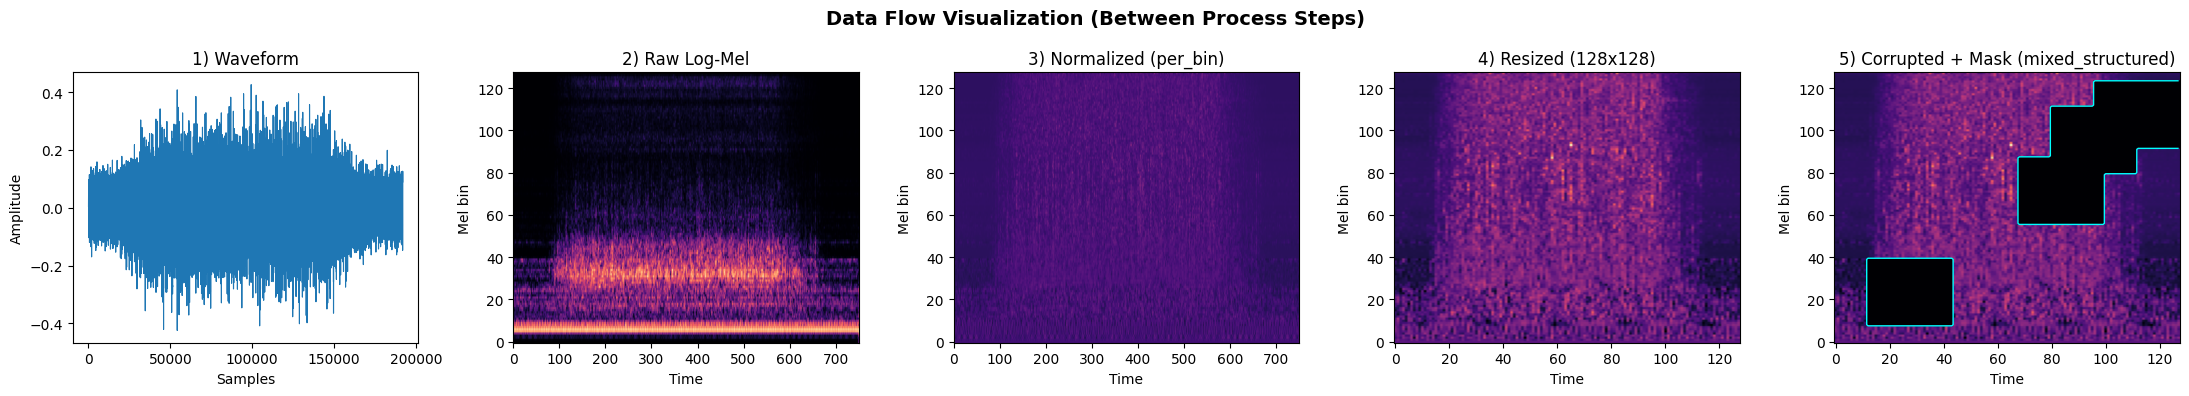

Visualized sample: C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779\dev_ToyCar\ToyCar\train\section_00_source_train_normal_0040_car_B2_spd_31V_mic_1.wav
QUIK_MODE: True, QUICK_TEST_MODE: True


In [6]:
# Visualize the data through intermediate processing steps.
# Run this after Cells 1-3 (imports, config, and utility functions).

viz_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE1_MACHINE_TYPES,
    "train",
    max_per_machine=1,
    seed=SUBSET_SEED,
)

if len(viz_files) == 0:
    raise RuntimeError("No training .wav files found. Check DATA_ROOT and dataset layout.")

viz_path = viz_files[VISUALIZE_INDEX % len(viz_files)]
waveform = load_waveform(viz_path)
mel_transform_v2 = build_mel_transform(f_cfg)

# Step 1: log-mel spectrogram (before normalization)
spec_raw = torch.log1p(mel_transform_v2(waveform)).unsqueeze(0)

# Step 2: normalization
spec_norm = normalize_spec(spec_raw.clone(), f_cfg["norm"])

# Step 3: model-ready resize to SPEC_SIZE x SPEC_SIZE
spec_model = F.interpolate(
    spec_norm.unsqueeze(0),
    size=(SPEC_SIZE, SPEC_SIZE),
    mode="bilinear",
    align_corners=False,
).squeeze(0)

# Step 4: synthetic anomaly mask from current corruption config
z_dummy = F.avg_pool2d(spec_model.unsqueeze(0), kernel_size=4, stride=4)
mask_latent = make_corruption_mask(
    z_dummy,
    mode=c_cfg["mode"],
    ratio=c_cfg["ratio"],
    block_hw=c_cfg["block_hw"],
    low_res=c_cfg["low_res"],
    anomaly_batch_ratio=1.0,
)
mask_full = F.interpolate(mask_latent.float(), size=spec_model.shape[-2:], mode="nearest").squeeze().cpu().numpy()

spec_np = spec_model.squeeze().detach().cpu().numpy()
spec_corrupted = spec_np.copy()
spec_corrupted[mask_full > 0.5] = spec_np.min()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Data Flow Visualization (Between Process Steps)", fontsize=14, fontweight="bold")

axes[0].plot(waveform.detach().cpu().numpy(), linewidth=0.8)
axes[0].set_title("1) Waveform")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Amplitude")

axes[1].imshow(spec_raw.squeeze().detach().cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
axes[1].set_title("2) Raw Log-Mel")

axes[2].imshow(spec_norm.squeeze().detach().cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
axes[2].set_title(f"3) Normalized ({f_cfg['norm']})")

axes[3].imshow(spec_np, origin="lower", aspect="auto", cmap="magma")
axes[3].set_title(f"4) Resized ({SPEC_SIZE}x{SPEC_SIZE})")

axes[4].imshow(spec_corrupted, origin="lower", aspect="auto", cmap="magma")
axes[4].contour(mask_full, levels=[0.5], colors=["cyan"], linewidths=1.0)
axes[4].set_title(f"5) Corrupted + Mask ({c_cfg['mode']})")

for ax in axes[1:]:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.tight_layout()
plt.show()

print(f"Visualized sample: {viz_path}")
print(f"QUIK_MODE: {QUIK_MODE}, QUICK_TEST_MODE: {QUICK_TEST_MODE}")

## 2. Model Training
Two-stage training for the discrete autoencoder and the anomaly detector.

In [17]:
from typing import Dict, Optional

import torch.nn as nn


def build_temperature_schedule(start_temp, end_temp, epochs, mode="linear"):
    if epochs <= 1:
        return [float(end_temp)]
    if mode == "linear":
        return np.linspace(float(start_temp), float(end_temp), epochs).tolist()
    if mode == "cosine":
        steps = np.linspace(0.0, np.pi, epochs)
        weights = 0.5 * (1.0 + np.cos(steps))
        return (float(end_temp) + (float(start_temp) - float(end_temp)) * weights).tolist()
    if mode == "exponential":
        if start_temp <= 0 or end_temp <= 0:
            raise ValueError("Exponential annealing requires positive temperatures.")
        decay = (float(end_temp) / float(start_temp)) ** (1.0 / (epochs - 1))
        return [float(start_temp) * (decay ** i) for i in range(epochs)]
    raise ValueError(f"Unknown temperature schedule mode: {mode}")


class FeatureEncoder(nn.Module):
    def __init__(self, in_ch: int = 1, ch1: int = 64, ch2: int = 128):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, ch1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(ch1, ch2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(f1)
        return f1, f2


class VectorQuantizerSimple(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int, temperature: float = VQ_TEMPERATURE):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.temperature = temperature

    def forward(self, z):
        bsz, ch, h, w = z.shape
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, ch)
        distances = (
            z_flat.pow(2).sum(1, keepdim=True)
            - 2 * z_flat @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(1)
        )
        probs = F.softmax(-distances / self.temperature, dim=1)
        indices = probs.argmax(dim=1)
        z_soft = probs @ self.embedding.weight
        z_hard = self.embedding(indices)
        z_q = z_soft + (z_hard - z_soft).detach()
        z_q = z_q.view(bsz, h, w, ch).permute(0, 3, 1, 2)
        return z_q, indices, probs


class GeneralDecoderModule1(nn.Module):
    def __init__(self, ch1: int = 64, ch2: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(ch2, ch1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(ch1, ch1, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, q1):
        return self.net(q1)


class QuantizedDecoderModule2(nn.Module):
    def __init__(self, ch1: int = 64, ch2: int = 128):
        super().__init__()
        self.q1_proj = nn.Conv2d(ch2, ch1, kernel_size=1)
        self.to_img = nn.Sequential(
            nn.Conv2d(ch1 * 2, ch1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(ch1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
        )

    def forward(self, q1, q2):
        q1_up = F.interpolate(q1, size=q2.shape[-2:], mode="bilinear", align_corners=False)
        q1_up = self.q1_proj(q1_up)
        fused = torch.cat([q2, q1_up], dim=1)
        return self.to_img(fused)


class DiscreteAutoencoderPaper(nn.Module):
    def __init__(self, in_ch: int = 1, ch1: int = 64, ch2: int = 128, q1_embeddings: int = 512, q2_embeddings: int = 512):
        super().__init__()
        self.ch1 = ch1
        self.ch2 = ch2
        self.encoder = FeatureEncoder(in_ch=in_ch, ch1=ch1, ch2=ch2)
        self.vq1 = VectorQuantizerSimple(num_embeddings=q1_embeddings, embedding_dim=ch2)
        self.general_dec1 = GeneralDecoderModule1(ch1=ch1, ch2=ch2)
        self.pre_q2_proj = nn.Conv2d(ch1 * 2, ch1, kernel_size=1)
        self.vq2 = VectorQuantizerSimple(num_embeddings=q2_embeddings, embedding_dim=ch1)
        self.general_dec2 = QuantizedDecoderModule2(ch1=ch1, ch2=ch2)

    def encode_features(self, x):
        return self.encoder(x)

    def quantize_features(self, f1, f2):
        q1, q1_idx, q1_probs = self.vq1(f2)
        f_u = self.general_dec1(q1)
        pre_q2 = self.pre_q2_proj(torch.cat([f1, f_u], dim=1))
        q2, q2_idx, q2_probs = self.vq2(pre_q2)
        return q1, q2, pre_q2, q1_idx, q2_idx, q1_probs, q2_probs

    def decode_general(self, q1, q2):
        return self.general_dec2(q1, q2)

    def forward(self, x):
        f1, f2 = self.encode_features(x)
        q1, q2, pre_q2, q1_idx, q2_idx, q1_probs, q2_probs = self.quantize_features(f1, f2)
        x_out = self.decode_general(q1, q2)
        return {
            "x_out": x_out,
            "f1": f1,
            "f2": f2,
            "pre_q2": pre_q2,
            "q1": q1,
            "q2": q2,
            "q1_idx": q1_idx,
            "q2_idx": q2_idx,
            "q1_probs": q1_probs,
            "q2_probs": q2_probs,
        }


class PaperAnomalyDetector(nn.Module):
    def __init__(self, width: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def forward(self, x_general, x_specific):
        x = torch.cat([x_general, x_specific], dim=1)
        return torch.sigmoid(self.net(x))


class AudDSRPaperLike(nn.Module):
    def __init__(
        self,
        ch1: int = 64,
        ch2: int = 128,
        q1_embeddings: int = 512,
        q2_embeddings: int = 512,
        corruption_cfg: Optional[Dict] = None,
        detector_cfg: Optional[Dict] = None,
        discrete_ae: Optional[DiscreteAutoencoderPaper] = None,
    ):
        super().__init__()

        if discrete_ae is None:
            self.discrete_ae = DiscreteAutoencoderPaper(
                in_ch=1,
                ch1=ch1,
                ch2=ch2,
                q1_embeddings=q1_embeddings,
                q2_embeddings=q2_embeddings,
            )
        else:
            self.discrete_ae = discrete_ae
            ch1 = self.discrete_ae.ch1
            ch2 = self.discrete_ae.ch2

        self.object_specific_decoder = QuantizedDecoderModule2(ch1=ch1, ch2=ch2)
        self.object_specific_decoder.load_state_dict(self.discrete_ae.general_dec2.state_dict())

        detector_cfg = detector_cfg or {"width": 32}
        self.detector = PaperAnomalyDetector(width=detector_cfg["width"])

        self.corruption_cfg = corruption_cfg or {
            "mode": "band_time",
            "ratio": 0.2,
            "block_hw": (8, 8),
            "low_res": (8, 8),
        }

    def freeze_discrete_modules(self):
        self.discrete_ae.eval()
        for p in self.discrete_ae.parameters():
            p.requires_grad = False

    def _sample_random_codes(self, quantizer, ref_tensor):
        bsz, _, h, w = ref_tensor.shape
        idx = torch.randint(0, quantizer.embedding.num_embeddings, (bsz, h, w), device=ref_tensor.device)
        sampled = quantizer.embedding(idx).permute(0, 3, 1, 2).contiguous()
        return sampled

    def forward(self, x, file_paths=None, apply_anomaly: bool = False, anomaly_batch_ratio: float = 1.0):
        with torch.no_grad():
            dae_out = self.discrete_ae(x)
            q1 = dae_out["q1"]
            q2 = dae_out["q2"]
            x_general = dae_out["x_out"]

        if apply_anomaly:
            mask_q1 = make_corruption_mask(
                q1,
                mode=self.corruption_cfg["mode"],
                ratio=self.corruption_cfg["ratio"],
                block_hw=tuple(self.corruption_cfg["block_hw"]),
                low_res=tuple(self.corruption_cfg.get("low_res", (8, 8))),
                anomaly_batch_ratio=anomaly_batch_ratio,
                mask_dilation=int(self.corruption_cfg.get("mask_dilation", 0)),
            )
            mask_q2 = F.interpolate(mask_q1.float(), size=q2.shape[-2:], mode="nearest").bool()

            random_q1 = self._sample_random_codes(self.discrete_ae.vq1, q1)
            random_q2 = self._sample_random_codes(self.discrete_ae.vq2, q2)

            q1_aug = torch.where(mask_q1.expand_as(q1), random_q1, q1)
            q2_aug = torch.where(mask_q2.expand_as(q2), random_q2, q2)
        else:
            mask_q1 = torch.zeros((q1.shape[0], 1, q1.shape[2], q1.shape[3]), device=q1.device, dtype=torch.bool)
            mask_q2 = F.interpolate(mask_q1.float(), size=q2.shape[-2:], mode="nearest").bool()
            q1_aug = q1
            q2_aug = q2

        x_specific = self.object_specific_decoder(q1_aug, q2_aug)
        anomaly_map = self.detector(x_general, x_specific)

        return {
            "x_general": x_general,
            "x_specific": x_specific,
            "x_out": x_general,
            "x_clean": x_specific,
            "anomaly_map": anomaly_map,
            "mask": mask_q1,
            "mask_q2": mask_q2,
            "q1": q1,
            "q2": q2,
            "q1_aug": q1_aug,
            "q2_aug": q2_aug,
        }


def codebook_usage_penalty(probs):
    probs_flat = probs.reshape(-1, probs.shape[-1])
    usage = probs_flat.mean(dim=0)
    usage = usage / usage.sum().clamp_min(STAGE1_USAGE_EPS)
    return (usage * usage.clamp_min(STAGE1_USAGE_EPS).log()).sum()


def binary_focal_loss(prob, target, alpha: float = 0.25, gamma: float = 2.0, eps: float = 1e-6):
    prob = prob.clamp(min=eps, max=1.0 - eps)
    ce = -(target * torch.log(prob) + (1.0 - target) * torch.log(1.0 - prob))
    pt = target * prob + (1.0 - target) * (1.0 - prob)
    alpha_t = target * alpha + (1.0 - target) * (1.0 - alpha)
    loss = alpha_t * ((1.0 - pt) ** gamma) * ce
    return loss.mean()


def weighted_bce_loss(prob, target, pos_weight: float = 1.0, eps: float = 1e-6):
    prob = prob.clamp(min=eps, max=1.0 - eps)
    return (-(pos_weight * target * torch.log(prob) + (1.0 - target) * torch.log(1.0 - prob))).mean()


def stage1_vqvae_loss(x, outputs, lambda_x: float = 1.0, lambda_k: float = 0.25):
    rec = F.mse_loss(outputs["x_out"], x)
    q1_codebook = F.mse_loss(outputs["f2"].detach(), outputs["q1"])
    q1_commit = F.mse_loss(outputs["f2"], outputs["q1"].detach())
    q2_codebook = F.mse_loss(outputs["pre_q2"].detach(), outputs["q2"])
    q2_commit = F.mse_loss(outputs["pre_q2"], outputs["q2"].detach())
    q1_usage = codebook_usage_penalty(outputs["q1_probs"])
    q2_usage = codebook_usage_penalty(outputs["q2_probs"])

    total = (
        lambda_x * rec
        + q1_codebook
        + lambda_k * q1_commit
        + q2_codebook
        + lambda_k * q2_commit
        + STAGE1_CODEBOOK_USAGE_WEIGHT * (q1_usage + q2_usage)
    )

    return total, {
        "total": float(total.item()),
        "rec": float(rec.item()),
        "q1_cb": float(q1_codebook.item()),
        "q1_cm": float(q1_commit.item()),
        "q2_cb": float(q2_codebook.item()),
        "q2_cm": float(q2_commit.item()),
        "q1_usage": float(q1_usage.item()),
        "q2_usage": float(q2_usage.item()),
    }


def stage2_auddsr_loss(
    x,
    outputs,
    lambda_rec: float = 1.0,
    lambda_det: float = 1.0,
    alpha: float = 0.25,
    gamma: float = 2.0,
    pos_weight: float = 8.0,
    focal_mix: float = 0.5,
    margin_weight: float = 1.0,
    margin_target: float = 0.10,
):
    rec_specific = F.mse_loss(outputs["x_specific"], x)
    det_target = F.interpolate(outputs["mask"].float(), size=x.shape[-2:], mode="nearest")
    det_focal = binary_focal_loss(outputs["anomaly_map"], det_target, alpha=alpha, gamma=gamma)
    det_bce = weighted_bce_loss(outputs["anomaly_map"], det_target, pos_weight=pos_weight)
    det_loss = focal_mix * det_focal + (1.0 - focal_mix) * det_bce

    det_margin = torch.zeros((), device=x.device, dtype=det_loss.dtype)
    flat_map = outputs["anomaly_map"].view(outputs["anomaly_map"].shape[0], -1)
    flat_target = det_target.view(det_target.shape[0], -1) > 0.5
    margin_terms = []
    for sample_map, sample_target in zip(flat_map, flat_target):
        if sample_target.any() and (~sample_target).any():
            pos_mean = sample_map[sample_target].mean()
            neg_mean = sample_map[~sample_target].mean()
            margin_terms.append(F.relu(margin_target - (pos_mean - neg_mean)))
    if margin_terms:
        det_margin = torch.stack(margin_terms).mean()

    total = lambda_rec * rec_specific + lambda_det * det_loss + margin_weight * det_margin
    return total, {
        "total": float(total.item()),
        "rec_specific": float(rec_specific.item()),
        "det": float(det_loss.item()),
        "det_focal": float(det_focal.item()),
        "det_bce": float(det_bce.item()),
        "det_margin": float(det_margin.item()),
    }


print("[Models] Model and loss helpers loaded.")

[Models] Model and loss helpers loaded.


In [18]:
# ============================================================================
# Full Two-Stage Training: Stage 1 (Discrete VQ-VAE) + Stage 2 (AudDSR)
# ============================================================================

# Build mel transform from frontend config
mel_transform_v2 = build_mel_transform(f_cfg)
stage1_temp_schedule = build_temperature_schedule(STAGE1_TEMP_START, STAGE1_TEMP_END, STAGE1_EPOCHS, mode=STAGE1_TEMP_MODE)

# --- Data Load & Preparation ---
print("[Training] Collecting wav files for Stage 1 and Stage 2...")

# Build Stage 1 dataset (all machine types, training split)
stage1_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE1_MACHINE_TYPES,
    "train",
    max_per_machine=SUBSET_TRAIN_PER_MACHINE if SUBSET_TRAIN_PER_MACHINE > 0 else 0,
    seed=SUBSET_SEED
)

stage1_dataset = SpectrogramFileDataset(stage1_files, mel_transform_v2, f_cfg)
train_loader_s1 = DataLoader(stage1_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"[Training] Stage 1: {len(stage1_files)} files, {len(train_loader_s1)} batches")

# Build Stage 2 dataset (all machine types, training split)
stage2_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    "train",
    max_per_machine=SUBSET_TRAIN_PER_MACHINE if SUBSET_TRAIN_PER_MACHINE > 0 else 0,
    seed=SUBSET_SEED
)

stage2_dataset = SpectrogramFileDataset(stage2_files, mel_transform_v2, f_cfg)
train_loader_v2 = DataLoader(stage2_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
monitor_batch_size = max(1, min(BATCH_SIZE, len(stage2_dataset)))
monitor_loader_v2 = DataLoader(stage2_dataset, batch_size=monitor_batch_size, shuffle=False, num_workers=0)
monitor_batch_v2 = next(iter(monitor_loader_v2))
monitor_x_v2 = monitor_batch_v2[0].to(device)
monitor_paths_v2 = monitor_batch_v2[1]
print(f"[Training] Stage 2: {len(stage2_files)} files, {len(train_loader_v2)} batches")
print(f"[Training] Stage 1 temperature schedule: {stage1_temp_schedule}")

# --- Stage 1: Discrete VQ-VAE Training ---
print("\n" + "="*70)
print("STAGE 1: Discrete VQ-VAE Training")
print("="*70)

discrete_ae = DiscreteAutoencoderPaper(
    in_ch=1,
    ch1=f_cfg.get("ch1", 64),
    ch2=f_cfg.get("ch2", 128),
    q1_embeddings=q_cfg.get("q1_embeddings", 1024),
    q2_embeddings=q_cfg.get("q2_embeddings", 1024),
).to(device)

optimizer_stage1 = torch.optim.Adam(discrete_ae.parameters(), lr=LR_STAGE1)
stage1_loss_history = {
    "total": [],
    "rec": [],
    "q1_cb": [],
    "q1_cm": [],
    "q2_cb": [],
    "q2_cm": [],
    "q1_usage": [],
    "q2_usage": [],
    "temperature": [],
}

discrete_ae.train()
for epoch in range(1, STAGE1_EPOCHS + 1):
    current_temperature = stage1_temp_schedule[min(epoch - 1, len(stage1_temp_schedule) - 1)]
    discrete_ae.vq1.temperature = current_temperature
    discrete_ae.vq2.temperature = current_temperature

    running = {
        "total": 0.0,
        "rec": 0.0,
        "q1_cb": 0.0,
        "q1_cm": 0.0,
        "q2_cb": 0.0,
        "q2_cm": 0.0,
        "q1_usage": 0.0,
        "q2_usage": 0.0,
    }

    for batch in train_loader_s1:
        x, _ = batch
        x = x.to(device)

        optimizer_stage1.zero_grad()
        outputs = discrete_ae(x)
        loss, parts = stage1_vqvae_loss(x, outputs, lambda_x=LAMBDA_X, lambda_k=LAMBDA_K)
        loss.backward()
        optimizer_stage1.step()

        for key in running:
            running[key] += parts[key]

    n_batches = max(1, len(train_loader_s1))

    # Record epoch-level losses
    for key in stage1_loss_history:
        if key == "temperature":
            stage1_loss_history[key].append(current_temperature)
        else:
            stage1_loss_history[key].append(running[key] / n_batches)

    print(
        f"[Stage1] Epoch {epoch}/{STAGE1_EPOCHS} | temp={current_temperature:.3f} | "
        f"total={running['total']/n_batches:.4f} | "
        f"rec={running['rec']/n_batches:.4f} | "
        f"q1_cb={running['q1_cb']/n_batches:.4f} | "
        f"q1_cm={running['q1_cm']/n_batches:.4f} | "
        f"q2_cb={running['q2_cb']/n_batches:.4f} | "
        f"q2_cm={running['q2_cm']/n_batches:.4f} | "
        f"q1_usage={running['q1_usage']/n_batches:.4f} | "
        f"q2_usage={running['q2_usage']/n_batches:.4f}"
    )

print("\n[Stage1] Training complete.")

# --- Stage 2: Object-Specific Decoder + Anomaly Detector ---
print("\n" + "="*70)
print("STAGE 2: Object-Specific Decoder + Anomaly Detector Training")
print("="*70)

# Create Stage 2 model with trained discrete AE
paper_model = AudDSRPaperLike(
    ch1=f_cfg.get("ch1", 64),
    ch2=f_cfg.get("ch2", 128),
    q1_embeddings=q_cfg.get("q1_embeddings", 1024),
    q2_embeddings=q_cfg.get("q2_embeddings", 1024),
    corruption_cfg=c_cfg,
    detector_cfg=d_cfg,
    discrete_ae=discrete_ae,  # Use trained Stage 1 model
).to(device)

paper_model.freeze_discrete_modules()

# Optimizer only for trainable parts (decoder + detector)
trainable_params = list(paper_model.object_specific_decoder.parameters()) + list(paper_model.detector.parameters())
optimizer_stage2 = torch.optim.Adam(trainable_params, lr=LR_STAGE2)

stage2_loss_history = {
    "total": [],
    "rec_specific": [],
    "det": [],
    "det_focal": [],
    "det_bce": [],
}
stage2_diagnostics_history = {
    "mask_frac": [],
    "map_mask_mean": [],
    "map_bg_mean": [],
    "map_gap": [],
    "clean_map_mean": [],
    "clean_rec_mse": [],
    "anom_rec_mse": [],
}

paper_model.train()
for epoch in range(1, STAGE2_EPOCHS + 1):
    running = {
        "total": 0.0,
        "rec_specific": 0.0,
        "det": 0.0,
        "det_focal": 0.0,
        "det_bce": 0.0,
    }

    # IMPROVEMENT: Get epoch-specific corruption ratio for progressive hardening
    if ENABLE_PROGRESSIVE_CORRUPTION:
        epoch_corruption_ratio = CORRUPTION_RATIO_SCHEDULE[min(epoch - 1, len(CORRUPTION_RATIO_SCHEDULE) - 1)]
        original_ratio = c_cfg["ratio"]
        c_cfg["ratio"] = epoch_corruption_ratio
    else:
        epoch_corruption_ratio = c_cfg["ratio"]

    for batch in train_loader_v2:
        x, paths = batch
        x = x.to(device)

        optimizer_stage2.zero_grad()
        outputs = paper_model(
            x,
            file_paths=paths,
            apply_anomaly=True,
            anomaly_batch_ratio=STAGE2_ANOMALY_BATCH_RATIO,
        )
        loss, parts = stage2_auddsr_loss(
            x,
            outputs,
            lambda_rec=LAMBDA_STAGE2_REC,
            lambda_det=LAMBDA_STAGE2_DET,
            alpha=FOCAL_ALPHA,
            gamma=FOCAL_GAMMA,
            pos_weight=DET_POS_WEIGHT,
            focal_mix=0.5,
        )
        loss.backward()
        optimizer_stage2.step()

        for key in running:
            running[key] += parts[key]

    n_batches = max(1, len(train_loader_v2))

    # Record epoch-level losses
    for key in stage2_loss_history:
        stage2_loss_history[key].append(running[key] / n_batches)

    paper_model.eval()
    with torch.no_grad():
        clean_monitor = paper_model(monitor_x_v2, file_paths=monitor_paths_v2, apply_anomaly=False)
        anom_monitor = paper_model(monitor_x_v2, file_paths=monitor_paths_v2, apply_anomaly=True, anomaly_batch_ratio=1.0)
        clean_map = clean_monitor["anomaly_map"]
        anom_map = anom_monitor["anomaly_map"]
        target_map = F.interpolate(anom_monitor["mask"].float(), size=anom_map.shape[-2:], mode="nearest")
        active_mask = target_map > 0.5
        inactive_mask = ~active_mask
        mask_frac = float(target_map.mean().item())
        map_mask_mean = float(anom_map[active_mask].mean().item()) if active_mask.any() else float(anom_map.mean().item())
        map_bg_mean = float(anom_map[inactive_mask].mean().item()) if inactive_mask.any() else map_mask_mean
        map_gap = map_mask_mean - map_bg_mean
        clean_map_mean = float(clean_map.mean().item())
        clean_rec_mse = float(F.mse_loss(clean_monitor["x_specific"], monitor_x_v2).item())
        anom_rec_mse = float(F.mse_loss(anom_monitor["x_specific"], monitor_x_v2).item())

    stage2_diagnostics_history["mask_frac"].append(mask_frac)
    stage2_diagnostics_history["map_mask_mean"].append(map_mask_mean)
    stage2_diagnostics_history["map_bg_mean"].append(map_bg_mean)
    stage2_diagnostics_history["map_gap"].append(map_gap)
    stage2_diagnostics_history["clean_map_mean"].append(clean_map_mean)
    stage2_diagnostics_history["clean_rec_mse"].append(clean_rec_mse)
    stage2_diagnostics_history["anom_rec_mse"].append(anom_rec_mse)

    print(
        f"[Stage2] Epoch {epoch}/{STAGE2_EPOCHS} (corr_ratio={epoch_corruption_ratio:.2f}) | "
        f"total={running['total']/n_batches:.4f} | "
        f"rec_specific={running['rec_specific']/n_batches:.4f} | "
        f"det={running['det']/n_batches:.4f} | "
        f"focal={running['det_focal']/n_batches:.4f} | "
        f"wbce={running['det_bce']/n_batches:.4f}"
    )
    print(
        f"[Stage2][Diag] mask_frac={mask_frac:.3f} | map_mask={map_mask_mean:.4f} | "
        f"map_bg={map_bg_mean:.4f} | gap={map_gap:.4f} | clean_map={clean_map_mean:.4f} | "
        f"clean_rec={clean_rec_mse:.4f} | anom_rec={anom_rec_mse:.4f}"
    )
    if map_gap < 0.02:
        print("[Stage2][Warn] Detector separation is weak; try stronger corruption or a wider detector.")
    if anom_rec_mse <= clean_rec_mse:
        print("[Stage2][Warn] Synthetic corruption is not increasing reconstruction error enough.")

    if ENABLE_PROGRESSIVE_CORRUPTION:
        c_cfg["ratio"] = original_ratio
    paper_model.train()

print("\nTwo-stage paper-like training pass complete.")

[Training] Collecting wav files for Stage 1 and Stage 2...
[Training] Stage 1: 7000 files, 875 batches
[Training] Stage 2: 7000 files, 875 batches
[Training] Stage 1 temperature schedule: [1.8, 1.55, 1.3, 1.05, 0.8]

STAGE 1: Discrete VQ-VAE Training


KeyboardInterrupt: 

## 3. Model Evaluation / Analysis
Calibration, audit, and mechanism-based analysis.

Codebook usage diagnostics:
- Q1 usage:      0.0332
- Q1 perplexity: 21.44
- Q2 usage:      0.0391
- Q2 perplexity: 23.97
[Diag][Warn] Codebook collapse is still likely.
Calibration diagnostics:
- calibration files:        175
- final detector gap:       0.7895
- audit rec/map weights:    0.85 / 0.15
- rec score mu/sigma:       0.8322 / 0.0202
- map score mu/sigma:       0.3234 / 0.0385
- calibrated threshold:     1.9322
- calibration quantile:     0.99


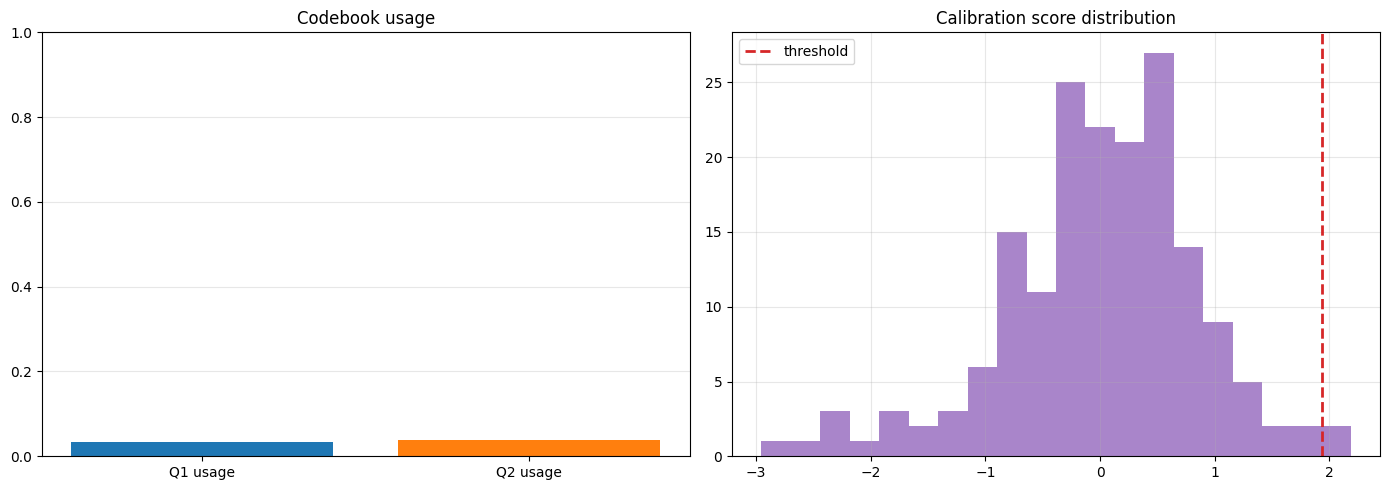

In [ ]:
# Calibration and codebook diagnostics.
if "paper_model" not in globals():
    raise RuntimeError("Run the training cell first so paper_model exists.")
if "monitor_x_v2" not in globals():
    raise RuntimeError("Run the training cell first so monitor_x_v2 exists.")

paper_model.eval()
discrete_ae.eval()

# Inspect quantizer usage on the same monitor batch used during training diagnostics.
with torch.no_grad():
    stage1_monitor = discrete_ae(monitor_x_v2)
    q1_usage, q1_ppl = quantizer_usage_stats(stage1_monitor["q1_idx"], q_cfg["q1_embeddings"])
    q2_usage, q2_ppl = quantizer_usage_stats(stage1_monitor["q2_idx"], q_cfg["q2_embeddings"])

print("Codebook usage diagnostics:")
print(f"- Q1 usage:      {q1_usage:.4f}")
print(f"- Q1 perplexity: {q1_ppl:.2f}")
print(f"- Q2 usage:      {q2_usage:.4f}")
print(f"- Q2 perplexity: {q2_ppl:.2f}")
if q1_usage < 0.10 or q2_usage < 0.10:
    print("[Diag][Warn] Codebook collapse is still likely.")

# Calibration threshold from normal training files.
calibration_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    "train",
    max_per_machine=CALIBRATION_FILES_PER_MACHINE,
    seed=SUBSET_SEED + 101,
)

if len(calibration_files) == 0:
    raise RuntimeError("Calibration file collection returned no files.")

if "stage2_diagnostics_history" in globals() and len(stage2_diagnostics_history["map_gap"]) > 0:
    final_gap = stage2_diagnostics_history["map_gap"][-1]
else:
    final_gap = 0.0

audit_map_weight = AUDIT_MAP_WEIGHT if final_gap >= MAP_GAP_BLEND_THRESHOLD else 0.0
audit_rec_weight = 1.0 - audit_map_weight


def calibration_file_components(file_path):
    waveform = load_waveform(file_path)
    x = waveform_to_model_input(waveform, mel_transform_v2, f_cfg).unsqueeze(0).to(device)
    with torch.no_grad():
        out = paper_model(x, apply_anomaly=False)
    rec_score = float(torch.abs(x - out["x_specific"]).mean().item())
    map_score = float(anomaly_map_to_file_score(out["anomaly_map"], topk_ratio=TOPK_RATIO).mean().item())
    return rec_score, map_score

calibration_pairs = [calibration_file_components(path) for path in calibration_files]
calibration_rec_scores = np.asarray([pair[0] for pair in calibration_pairs], dtype=np.float32)
calibration_map_scores = np.asarray([pair[1] for pair in calibration_pairs], dtype=np.float32)

calibration_rec_mu = float(calibration_rec_scores.mean())
calibration_rec_sigma = float(calibration_rec_scores.std() + 1e-6)
calibration_map_mu = float(calibration_map_scores.mean())
calibration_map_sigma = float(calibration_map_scores.std() + 1e-6)

calibration_scores = (
    audit_rec_weight * ((calibration_rec_scores - calibration_rec_mu) / calibration_rec_sigma)
    + audit_map_weight * ((calibration_map_scores - calibration_map_mu) / calibration_map_sigma)
)
calibration_score_mu = float(calibration_scores.mean())
calibration_score_sigma = float(calibration_scores.std() + 1e-6)
audit_threshold = float(np.quantile(calibration_scores, CALIBRATION_QUANTILE))

print("Calibration diagnostics:")
print(f"- calibration files:        {len(calibration_files)}")
print(f"- final detector gap:       {final_gap:.4f}")
print(f"- audit rec/map weights:    {audit_rec_weight:.2f} / {audit_map_weight:.2f}")
print(f"- rec score mu/sigma:       {calibration_rec_mu:.4f} / {calibration_rec_sigma:.4f}")
print(f"- map score mu/sigma:       {calibration_map_mu:.4f} / {calibration_map_sigma:.4f}")
print(f"- calibrated threshold:     {audit_threshold:.4f}")
print(f"- calibration quantile:     {CALIBRATION_QUANTILE}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(["Q1 usage", "Q2 usage"], [q1_usage, q2_usage], color=["#1f77b4", "#ff7f0e"])
ax[0].set_ylim(0, 1)
ax[0].set_title("Codebook usage")
ax[0].grid(True, axis="y", alpha=0.3)

ax[1].hist(calibration_scores, bins=20, color="#9467bd", alpha=0.8)
ax[1].axvline(audit_threshold, color="#d62728", linestyle="--", linewidth=2, label="threshold")
ax[1].set_title("Calibration score distribution")
ax[1].legend(loc="best")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

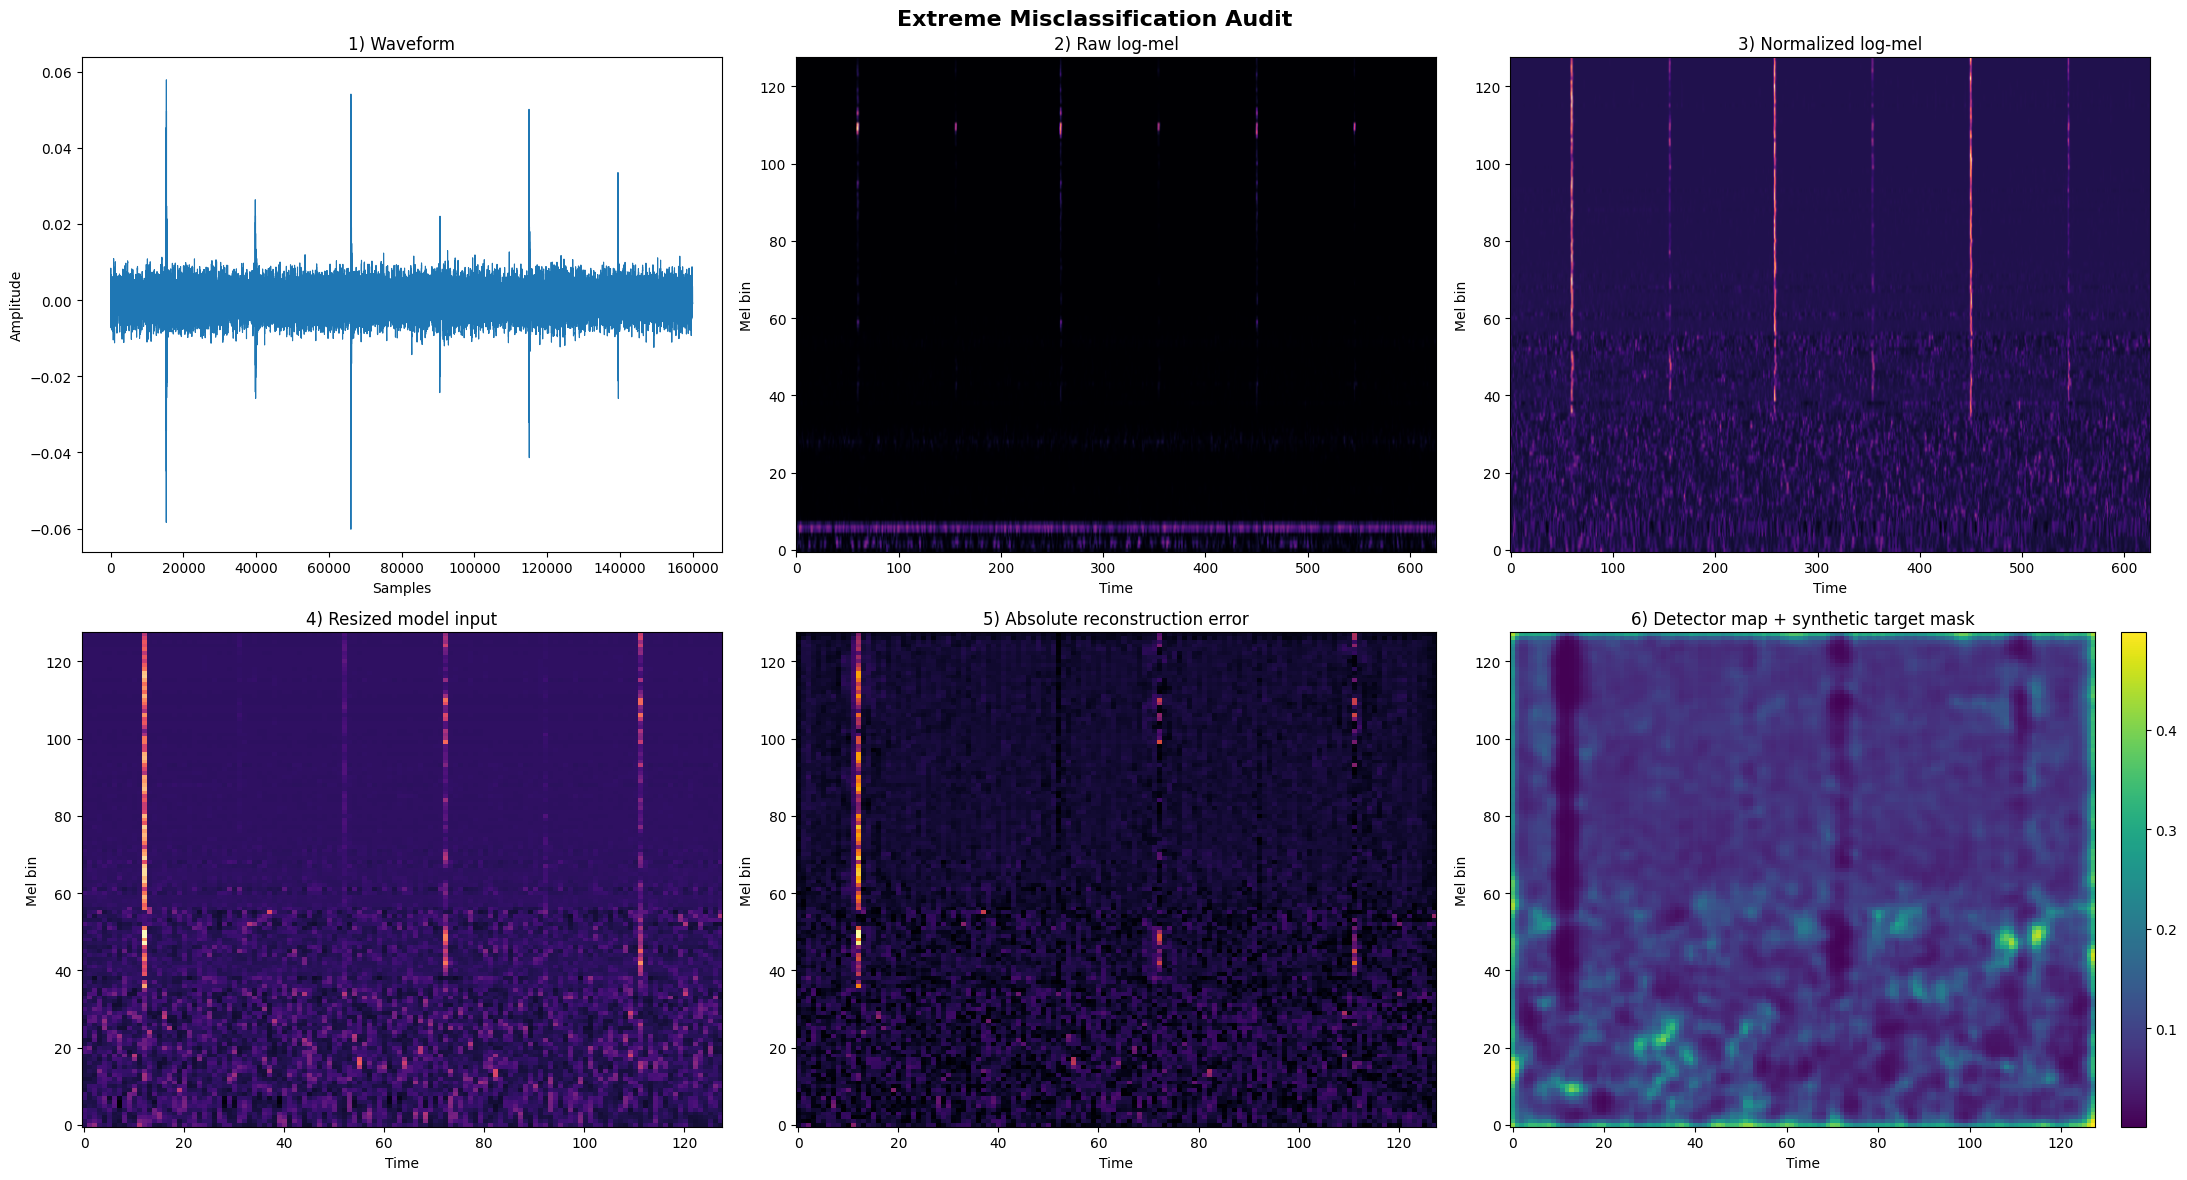

Chosen sample: C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779\dev_valve\valve\test\section_00_target_test_anomaly_0020_v1pat_04_v2pat_05.wav
True label: anomaly
Predicted label: normal
Mistake type: false negative
Threshold source: calibrated from train-normal scores
Threshold used: 1.9322
Combined file score: -1.9456
Pseudo-probability of anomaly: 0.0000
Mistake confidence: 1.0000
Reconstruction score (z): -2.0982 | raw: 0.7898
Map score (z): -1.0805 | raw: 0.2818
Audit score weights: 0.85 / 0.15
Processing path:
  1. waveform -> log-mel spectrogram
  2. spectrogram normalization
  3. resize to 128x128
  4. frozen discrete AE produces clean reconstruction
  5. reconstruction error is converted to a z-scored file score
  6. detector map is reduced to a top-k map score and z-scored
  7. standardized scores are blended into a composite anomaly score
  8. the composite score is thresholded into a file-level prediction


In [ ]:
# Extreme-mistake audit: show a sample the model is wildly wrong about and trace its processing.
if "paper_model" not in globals():
    raise RuntimeError("Run the training and evaluation cells first so paper_model exists.")
if "audit_threshold" not in globals():
    print("[Audit][Warn] No calibrated threshold found; using the audit batch median as fallback.")

# Collect a scored subset from the available test set.
audit_files = collect_multi_machine_split_files_limited(
    DATA_ROOT,
    STAGE2_MACHINE_TYPES,
    "test",
    max_per_machine=max(5, SUBSET_TEST_PER_MACHINE if SUBSET_TEST_PER_MACHINE > 0 else 5),
    seed=SUBSET_SEED + 17,
)

if len(audit_files) == 0:
    raise RuntimeError("No test files found for audit. Check DATA_ROOT and dataset layout.")


def file_level_anomaly_score(model_obj, file_path, topk_ratio=0.05):
    waveform = load_waveform(file_path)
    spec_raw = torch.log1p(mel_transform_v2(waveform)).unsqueeze(0)
    spec_norm = normalize_spec(spec_raw.clone(), f_cfg["norm"])
    spec_model = F.interpolate(
        spec_norm.unsqueeze(0),
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)
    x = spec_model.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model_obj(x, apply_anomaly=False)
        rec_err = torch.abs(x - out["x_specific"])
        anomaly_map = out["anomaly_map"]

    rec_raw = float(rec_err.mean().item())
    map_raw = float(anomaly_map_to_file_score(anomaly_map, topk_ratio=topk_ratio).mean().item())

    rec_mu = globals().get("calibration_rec_mu", rec_raw)
    rec_sigma = globals().get("calibration_rec_sigma", 1.0)
    map_mu = globals().get("calibration_map_mu", map_raw)
    map_sigma = globals().get("calibration_map_sigma", 1.0)

    rec_score = (rec_raw - rec_mu) / max(rec_sigma, 1e-6)
    map_score = (map_raw - map_mu) / max(map_sigma, 1e-6)
    rec_weight = globals().get("audit_rec_weight", REC_SCORE_WEIGHT)
    map_weight = globals().get("audit_map_weight", MAP_SCORE_WEIGHT)
    combined = rec_weight * rec_score + map_weight * map_score
    return {
        "waveform": waveform,
        "spec_raw": spec_raw.squeeze(0),
        "spec_norm": spec_norm.squeeze(0),
        "spec_model": spec_model,
        "x": x,
        "out": out,
        "rec_score": rec_score,
        "map_score": map_score,
        "rec_raw": rec_raw,
        "map_raw": map_raw,
        "combined": combined,
    }

audit_rows = []
for path in audit_files:
    label = infer_label_from_filename(path)
    if label is None:
        continue
    scores = file_level_anomaly_score(paper_model, path, topk_ratio=TOPK_RATIO)
    audit_rows.append({
        "path": path,
        "label": label,
        "score": scores["combined"],
        "rec_score": scores["rec_score"],
        "map_score": scores["map_score"],
        "rec_raw": scores["rec_raw"],
        "map_raw": scores["map_raw"],
        **scores,
    })

if len(audit_rows) == 0:
    raise RuntimeError("Could not infer labels from any sampled test file names.")

scores_np = np.asarray([row["score"] for row in audit_rows], dtype=np.float32)
labels_np = np.asarray([row["label"] for row in audit_rows], dtype=np.int32)
score_sigma = float(globals().get("calibration_score_sigma", scores_np.std() + 1e-6))

if "audit_threshold" in globals():
    threshold = float(audit_threshold)
    threshold_source = "calibrated from train-normal scores"
else:
    threshold = float(np.median(scores_np))
    threshold_source = "median of audited batch"

def score_to_prob(score):
    z = (score - threshold) / max(score_sigma, 1e-6)
    return float(1.0 / (1.0 + np.exp(-5.0 * z)))

for row in audit_rows:
    row["prob_anomaly"] = score_to_prob(row["score"])
    row["pred"] = int(row["prob_anomaly"] >= 0.5)
    row["confidence"] = float(abs(row["prob_anomaly"] - 0.5) * 2.0)

false_pos = [row for row in audit_rows if row["label"] == 0 and row["pred"] == 1 and row["prob_anomaly"] >= 0.95]
false_neg = [row for row in audit_rows if row["label"] == 1 and row["pred"] == 0 and row["prob_anomaly"] <= 0.05]

candidate_pool = false_pos + false_neg
if len(candidate_pool) == 0:
    candidate_pool = audit_rows

chosen = max(candidate_pool, key=lambda row: abs(row["prob_anomaly"] - 0.5))
chosen_true = int(chosen["label"])
chosen_pred = int(chosen["pred"])
chosen_prob = float(chosen["prob_anomaly"])
mistake_kind = "false positive" if chosen_true == 0 and chosen_pred == 1 else "false negative" if chosen_true == 1 and chosen_pred == 0 else "not a mistake"

waveform = chosen["waveform"].detach().cpu().numpy()
spec_raw_np = chosen["spec_raw"].detach().cpu().numpy()
spec_norm_np = chosen["spec_norm"].detach().cpu().numpy()
spec_model_np = chosen["spec_model"].detach().cpu().numpy()
x_np = chosen["x"].squeeze().detach().cpu().numpy()
out_np = chosen["out"]["x_specific"].squeeze().detach().cpu().numpy()
anom_map_np = chosen["out"]["anomaly_map"].squeeze().detach().cpu().numpy()
rec_err_np = np.abs(x_np - out_np)

with torch.no_grad():
    mask_for_demo = chosen["out"]["mask"].float()
    mask_for_demo = F.interpolate(mask_for_demo, size=anom_map_np.shape[-2:], mode="nearest").squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Extreme Misclassification Audit", fontsize=16, fontweight="bold")

axes[0, 0].plot(waveform, linewidth=0.8, color="#1f77b4")
axes[0, 0].set_title("1) Waveform")
axes[0, 0].set_xlabel("Samples")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].imshow(spec_raw_np, origin="lower", aspect="auto", cmap="magma")
axes[0, 1].set_title("2) Raw log-mel")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Mel bin")

axes[0, 2].imshow(spec_norm_np, origin="lower", aspect="auto", cmap="magma")
axes[0, 2].set_title("3) Normalized log-mel")
axes[0, 2].set_xlabel("Time")
axes[0, 2].set_ylabel("Mel bin")

axes[1, 0].imshow(spec_model_np.squeeze(), origin="lower", aspect="auto", cmap="magma")
axes[1, 0].set_title("4) Resized model input")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Mel bin")

axes[1, 1].imshow(rec_err_np, origin="lower", aspect="auto", cmap="inferno")
axes[1, 1].set_title("5) Absolute reconstruction error")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Mel bin")

im = axes[1, 2].imshow(anom_map_np, origin="lower", aspect="auto", cmap="viridis")
axes[1, 2].contour(mask_for_demo, levels=[0.5], colors=["cyan"], linewidths=1.0)
axes[1, 2].set_title("6) Detector map + synthetic target mask")
axes[1, 2].set_xlabel("Time")
axes[1, 2].set_ylabel("Mel bin")
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Chosen sample: {chosen['path']}")
print(f"True label: {'anomaly' if chosen_true == 1 else 'normal'}")
print(f"Predicted label: {'anomaly' if chosen_pred == 1 else 'normal'}")
print(f"Mistake type: {mistake_kind}")
print(f"Threshold source: {threshold_source}")
print(f"Threshold used: {threshold:.4f}")
print(f"Combined file score: {chosen['score']:.4f}")
print(f"Pseudo-probability of anomaly: {chosen_prob:.4f}")
print(f"Mistake confidence: {chosen['confidence']:.4f}")
print(f"Reconstruction score (z): {chosen['rec_score']:.4f} | raw: {chosen['rec_raw']:.4f}")
print(f"Map score (z): {chosen['map_score']:.4f} | raw: {chosen['map_raw']:.4f}")
print(f"Audit score weights: {globals().get('audit_rec_weight', REC_SCORE_WEIGHT):.2f} / {globals().get('audit_map_weight', MAP_SCORE_WEIGHT):.2f}")
print("Processing path:")
print("  1. waveform -> log-mel spectrogram")
print("  2. spectrogram normalization")
print(f"  3. resize to {SPEC_SIZE}x{SPEC_SIZE}")
print("  4. frozen discrete AE produces clean reconstruction")
print("  5. reconstruction error is converted to a z-scored file score")
print("  6. detector map is reduced to a top-k map score and z-scored")
print("  7. standardized scores are blended into a composite anomaly score")
print("  8. the composite score is thresholded into a file-level prediction")
if mistake_kind == "not a mistake":
    print("No extreme mistake found in this audit batch, so the cell showed the farthest borderline sample instead.")

In [9]:
# Paper-style mechanism-based analysis (-MA).
# This version adds machine-wise baselines and explicit time / frequency / time-frequency features.
from scipy import signal, stats

try:
    import pywt
except Exception:
    pywt = None

collect_split_files_fn = globals().get("collect_multi_machine_split_files_limited")
if collect_split_files_fn is None:
    collect_split_files_fn = globals().get("collect_multi_machine_split_files")
if collect_split_files_fn is None:
    raise RuntimeError("No file collection helper is available. Run the data utility cell first.")

infer_machine_fn = globals().get("infer_machine_type_from_path")
if infer_machine_fn is None:
    def infer_machine_fn(path):
        lower_path = str(path).lower()
        for machine in ALL_MACHINE_TYPES:
            if machine.lower() in lower_path:
                return machine
        return None

paper_machine_names = ["AutoTrash", "Polisher", "ScrewFeeder"]
matched_paper_machines = [
    name for name in paper_machine_names
    if any(name.lower() in str(path).lower() for path in globals().get("stage2_files", []))
]
if matched_paper_machines:
    mechanism_machine_types = matched_paper_machines
    mechanism_note = f"Paper machine names present in this dataset: {matched_paper_machines}"
else:
    mechanism_machine_types = list(STAGE2_MACHINE_TYPES)
    mechanism_note = (
        "The dataset does not contain AutoTrash / Polisher / ScrewFeeder paths, "
        "so the same MA pipeline is run per available machine type."
    )

print("[Mechanism-MA] Paper-style mechanism analysis")
print(f"[Mechanism-MA] {mechanism_note}")
print(f"[Mechanism-MA] Machines analyzed: {mechanism_machine_types}")


def _safe_entropy(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    total = float(values.sum())
    if total <= 0:
        return 0.0
    probs = values / total
    probs = probs[probs > 0]
    if probs.size == 0:
        return 0.0
    return float(-(probs * np.log(probs)).sum())


def estimate_characteristic_frequency(feature_dicts):
    dominant_freqs = [float(fd.get("dominant_freq", 0.0)) for fd in feature_dicts if float(fd.get("dominant_freq", 0.0)) > 0.0]
    if len(dominant_freqs) == 0:
        return 0.0
    return float(np.median(dominant_freqs))


def _collect_split_files(machine_type, split, max_per_machine, seed):
    try:
        files = collect_split_files_fn(
            DATA_ROOT,
            [machine_type],
            split,
            max_per_machine=max_per_machine,
            seed=seed,
        )
    except TypeError:
        files = collect_split_files_fn(DATA_ROOT, [machine_type], split)
        files = list(files)
        rng = np.random.default_rng(seed)
        rng.shuffle(files)
        files = files[:max_per_machine]
    return list(files)


def _to_numpy_waveform(waveform):
    if hasattr(waveform, "detach"):
        waveform = waveform.detach().cpu().numpy()
    waveform = np.asarray(waveform, dtype=np.float64)
    if waveform.ndim > 1:
        waveform = waveform.mean(axis=0)
    waveform = waveform.reshape(-1)
    waveform = waveform[np.isfinite(waveform)]
    return waveform


def extract_mechanism_features(waveform, sample_rate, reference_freq_hz=None):
    x = _to_numpy_waveform(waveform)
    if x.size == 0:
        zero_features = {
            "energy": 0.0,
            "rms": 0.0,
            "crest_factor": 0.0,
            "kurtosis": 0.0,
            "skewness": 0.0,
            "peak_to_peak": 0.0,
            "dominant_freq": 0.0,
            "fundamental_power_ratio": 0.0,
            "harmonic_ratio": 0.0,
            "sideband_ratio": 0.0,
            "spectral_centroid": 0.0,
            "spectral_rolloff": 0.0,
            "stft_entropy": 0.0,
            "stft_peak_ratio": 0.0,
            "stft_localization": 0.0,
            "wavelet_entropy": 0.0,
            "wavelet_peak_ratio": 0.0,
            "reference_freq_hz": 0.0,
            "reference_freq_error": 0.0,
        }
        return zero_features, {"stft_energy": np.zeros((1, 1), dtype=np.float64), "stft_freqs": np.array([0.0]), "stft_times": np.array([0.0])}

    x = x - float(x.mean())
    abs_x = np.abs(x)
    energy = float(np.mean(x ** 2))
    rms = float(np.sqrt(max(energy, 0.0)))
    crest_factor = float(abs_x.max() / max(rms, 1e-12))
    kurtosis = float(stats.kurtosis(x, fisher=False, bias=False)) if x.size > 3 else 0.0
    skewness = float(stats.skew(x, bias=False)) if x.size > 2 else 0.0
    peak_to_peak = float(np.ptp(x))

    nperseg = min(4096, max(256, x.size))
    noverlap = max(0, nperseg // 2)
    freqs, psd = signal.welch(x, fs=sample_rate, window="hann", nperseg=nperseg, noverlap=noverlap, detrend="constant")
    psd = np.asarray(psd, dtype=np.float64)
    freqs = np.asarray(freqs, dtype=np.float64)
    total_power = float(psd.sum()) + 1e-12
    if psd.size <= 1:
        dominant_idx = 0
    else:
        dominant_idx = int(np.argmax(psd[1:]) + 1)
    dominant_freq = float(freqs[dominant_idx]) if freqs.size else 0.0
    reference_freq = float(reference_freq_hz) if reference_freq_hz is not None and float(reference_freq_hz) > 0.0 else dominant_freq
    band_width = float(max(1.0, reference_freq * 0.05, sample_rate / max(x.size, 1) * 2.0))

    def band_power(center_freq, width_hz):
        if center_freq <= 0 or freqs.size == 0:
            return 0.0
        left = np.searchsorted(freqs, max(0.0, center_freq - width_hz), side="left")
        right = np.searchsorted(freqs, min(sample_rate / 2.0, center_freq + width_hz), side="right")
        if right <= left:
            return 0.0
        return float(psd[left:right].sum())

    fundamental_power = band_power(reference_freq, band_width)
    harmonic_power = 0.0
    sideband_power = 0.0
    for harmonic in range(2, 5):
        center = reference_freq * harmonic
        if center <= 0 or center >= sample_rate / 2.0:
            continue
        harmonic_power += band_power(center, band_width)
        sideband_power += band_power(center - 2.5 * band_width, 0.5 * band_width)
        sideband_power += band_power(center + 2.5 * band_width, 0.5 * band_width)

    fundamental_power_ratio = float(fundamental_power / total_power)
    harmonic_ratio = float(harmonic_power / total_power)
    sideband_ratio = float(sideband_power / total_power)

    spectral_centroid = float(np.sum(freqs * psd) / total_power) if freqs.size else 0.0
    cumulative = np.cumsum(psd)
    rolloff_idx = int(np.searchsorted(cumulative, 0.85 * total_power)) if psd.size else 0
    spectral_rolloff = float(freqs[min(rolloff_idx, len(freqs) - 1)]) if freqs.size else 0.0

    tf_nperseg = min(1024, max(64, x.size // 8))
    tf_noverlap = max(0, tf_nperseg // 2)
    stft_freqs, stft_times, stft_complex = signal.stft(
        x,
        fs=sample_rate,
        window="hann",
        nperseg=tf_nperseg,
        noverlap=tf_noverlap,
        boundary=None,
    )
    stft_energy = np.abs(stft_complex) ** 2
    stft_total = float(stft_energy.sum()) + 1e-12
    stft_entropy = _safe_entropy(stft_energy.ravel())
    stft_peak_ratio = float(stft_energy.max() / stft_total) if stft_energy.size else 0.0
    time_energy = stft_energy.sum(axis=0) if stft_energy.ndim == 2 and stft_energy.shape[1] > 0 else np.asarray([0.0])
    topk = max(1, int(np.ceil(0.1 * time_energy.size)))
    stft_localization = float(np.sort(time_energy)[-topk:].sum() / stft_total) if stft_total > 0 else 0.0

    wavelet_entropy = 0.0
    wavelet_peak_ratio = 0.0
    if pywt is not None and x.size >= 64:
        try:
            width_max = int(min(64, max(16, x.size // 128)))
            widths = np.arange(1, width_max + 1)
            coeffs, _ = pywt.cwt(x, widths, "morl", sampling_period=1.0 / sample_rate)
            wavelet_energy = np.sum(np.abs(coeffs) ** 2, axis=1)
            if np.isfinite(wavelet_energy).any() and wavelet_energy.sum() > 0:
                wavelet_entropy = _safe_entropy(wavelet_energy)
                wavelet_peak_ratio = float(wavelet_energy.max() / max(wavelet_energy.sum(), 1e-12))
        except Exception:
            pass

    features = {
        "energy": energy,
        "rms": rms,
        "crest_factor": crest_factor,
        "kurtosis": kurtosis,
        "skewness": skewness,
        "peak_to_peak": peak_to_peak,
        "dominant_freq": dominant_freq,
        "fundamental_power_ratio": fundamental_power_ratio,
        "harmonic_ratio": harmonic_ratio,
        "sideband_ratio": sideband_ratio,
        "spectral_centroid": spectral_centroid,
        "spectral_rolloff": spectral_rolloff,
        "stft_entropy": stft_entropy,
        "stft_peak_ratio": stft_peak_ratio,
        "stft_localization": stft_localization,
        "wavelet_entropy": wavelet_entropy,
        "wavelet_peak_ratio": wavelet_peak_ratio,
        "reference_freq_hz": reference_freq,
        "reference_freq_error": abs(dominant_freq - reference_freq) / max(reference_freq, 1e-12),
    }
    tf_info = {
        "stft_energy": stft_energy,
        "stft_freqs": stft_freqs,
        "stft_times": stft_times,
    }
    return features, tf_info


mechanism_feature_names = [
    "energy",
    "rms",
    "crest_factor",
    "kurtosis",
    "skewness",
    "peak_to_peak",
    "dominant_freq",
    "fundamental_power_ratio",
    "harmonic_ratio",
    "sideband_ratio",
    "spectral_centroid",
    "spectral_rolloff",
    "stft_entropy",
    "stft_peak_ratio",
    "stft_localization",
    "wavelet_entropy",
    "wavelet_peak_ratio",
]


def features_to_vector(feature_dict):
    return np.asarray([feature_dict[name] for name in mechanism_feature_names], dtype=np.float64)


mechanism_reports = []
mechanism_baseline_files = []
mechanism_probe_files = []

for machine_idx, machine_type in enumerate(mechanism_machine_types):
    train_files = _collect_split_files(machine_type, "train", CALIBRATION_FILES_PER_MACHINE, SUBSET_SEED + 401 + machine_idx)
    if len(train_files) == 0:
        continue

    train_waveforms = [load_waveform(path) for path in train_files]
    raw_train_feature_dicts = [extract_mechanism_features(waveform, TARGET_SR)[0] for waveform in train_waveforms]
    reference_freq_hz = estimate_characteristic_frequency(raw_train_feature_dicts)
    characteristic_targets_hz = [reference_freq_hz * harmonic for harmonic in range(1, 5)] if reference_freq_hz > 0 else []
    baseline_matrix = []
    for waveform in train_waveforms:
        feature_dict, _ = extract_mechanism_features(waveform, TARGET_SR, reference_freq_hz=reference_freq_hz)
        baseline_matrix.append(features_to_vector(feature_dict))
    baseline_matrix = np.asarray(baseline_matrix, dtype=np.float64)
    baseline_matrix_clean = np.where(np.isfinite(baseline_matrix), baseline_matrix, 0.0)

    feature_mean = baseline_matrix_clean.mean(axis=0)
    feature_std = baseline_matrix_clean.std(axis=0)
    feature_std = np.where(feature_std > 1e-6, feature_std, 1.0)

    train_z = (baseline_matrix_clean - feature_mean) / feature_std
    train_scores = np.sqrt(np.mean(train_z ** 2, axis=1))
    train_scores = np.nan_to_num(train_scores, nan=0.0, posinf=0.0, neginf=0.0)
    threshold = float(np.quantile(train_scores, CALIBRATION_QUANTILE))

    probe_candidates = [path for path in globals().get("audit_files", []) if infer_machine_fn(path) == machine_type]
    if len(probe_candidates) == 0:
        probe_candidates = _collect_split_files(machine_type, "test", max(1, SUBSET_TEST_PER_MACHINE if SUBSET_TEST_PER_MACHINE > 0 else 1), SUBSET_SEED + 701 + machine_idx)
    if len(probe_candidates) == 0:
        continue

    probe_path = probe_candidates[0]
    probe_waveform = load_waveform(probe_path)
    probe_feature_dict, probe_tf = extract_mechanism_features(probe_waveform, TARGET_SR, reference_freq_hz=reference_freq_hz)
    probe_vector = features_to_vector(probe_feature_dict)
    probe_vector_clean = np.where(np.isfinite(probe_vector), probe_vector, 0.0)
    probe_z = (probe_vector_clean - feature_mean) / feature_std
    probe_z = np.nan_to_num(probe_z, nan=0.0, posinf=0.0, neginf=0.0)
    probe_score = float(np.sqrt(np.mean(probe_z ** 2)))
    probe_flag = bool(probe_score > threshold)

    mechanism_baseline_files.extend(train_files)
    mechanism_probe_files.append(probe_path)
    mechanism_reports.append(
        {
            "machine": machine_type,
            "reference_freq_hz": reference_freq_hz,
            "characteristic_targets_hz": characteristic_targets_hz,
            "baseline_files": train_files,
            "probe_path": probe_path,
            "feature_mean": feature_mean,
            "feature_std": feature_std,
            "baseline_matrix": baseline_matrix_clean,
            "train_scores": train_scores,
            "threshold": threshold,
            "probe_vector": probe_vector_clean,
            "probe_z": probe_z,
            "probe_score": probe_score,
            "probe_flag": probe_flag,
            "probe_features": probe_feature_dict,
            "probe_tf": probe_tf,
        }
    )

if len(mechanism_reports) == 0:
    raise RuntimeError("Mechanism analysis could not build any machine-specific baselines.")

print("[Mechanism-MA] Per-machine baselines and characteristic targets:")
for report in mechanism_reports:
    target_text = ', '.join(f'{freq:.1f}' for freq in report['characteristic_targets_hz']) if len(report['characteristic_targets_hz']) > 0 else 'n/a'
    print(f"- {report['machine']}: ref={report['reference_freq_hz']:.1f} Hz | targets={target_text} | threshold={report['threshold']:.4f} | probe={report['probe_score']:.4f} | flag={report['probe_flag']}")

representative_report = max(mechanism_reports, key=lambda item: abs(item["probe_score"] - item["threshold"]))
mechanism_baseline_matrix = representative_report["baseline_matrix"]
mech_mean = representative_report["feature_mean"]
mech_std = representative_report["feature_std"]
mech_baseline_scores = representative_report["train_scores"]
mechanism_threshold = representative_report["threshold"]
mechanism_ma_score = representative_report["probe_score"]
mechanism_ma_flag = representative_report["probe_flag"]
probe_path = representative_report["probe_path"]
probe_vector = representative_report["probe_vector"]
probe_z = {name: float(value) for name, value in zip(mechanism_feature_names, representative_report["probe_z"])}
probe_features = representative_report["probe_features"]
reference_freq_hz = representative_report["reference_freq_hz"]
characteristic_targets_hz = representative_report["characteristic_targets_hz"]

print(f"[Mechanism-MA] Representative machine: {representative_report['machine']}")
print(f"[Mechanism-MA] Baseline files used: {len(representative_report['baseline_files'])}")
print(f"[Mechanism-MA] Features: {len(mechanism_feature_names)}")
print(f"[Mechanism-MA] Characteristic reference frequency: {reference_freq_hz:.1f} Hz")
if len(characteristic_targets_hz) > 0:
    print(f"[Mechanism-MA] Characteristic targets (Hz): {', '.join(f'{freq:.1f}' for freq in characteristic_targets_hz)}")
print(f"[Mechanism-MA] Threshold (q={CALIBRATION_QUANTILE}): {mechanism_threshold:.4f}")
print(f"[Mechanism-MA] Probe file: {probe_path}")
print(f"[Mechanism-MA] Probe score: {mechanism_ma_score:.4f}")
print(f"[Mechanism-MA] Flagged as anomaly: {mechanism_ma_flag}")

sorted_z = sorted(probe_z.items(), key=lambda item: abs(item[1]), reverse=True)
print("[Mechanism-MA] Top standardized deviations:")
for name, value in sorted_z[:6]:
    print(f"- {name}: {value:+.3f}")

feature_groups = {
    "time-domain": ["energy", "rms", "crest_factor", "kurtosis", "skewness", "peak_to_peak"],
    "frequency-domain": ["dominant_freq", "fundamental_power_ratio", "harmonic_ratio", "sideband_ratio", "spectral_centroid", "spectral_rolloff"],
    "time-frequency": ["stft_entropy", "stft_peak_ratio", "stft_localization", "wavelet_entropy", "wavelet_peak_ratio"],
}
for group_name, group_features in feature_groups.items():
    group_values = [abs(probe_z[name]) for name in group_features if name in probe_z]
    if len(group_values) > 0:
        print(f"[Mechanism-MA] {group_name} mean |z|: {float(np.mean(group_values)):.3f}")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle(f"Mechanism-Based Analysis (-MA) | {representative_report['machine']}", fontsize=16, fontweight="bold")

waveform = load_waveform(probe_path)
waveform_np = _to_numpy_waveform(waveform)
axes[0, 0].plot(waveform_np, linewidth=0.8, color="#1f77b4")
axes[0, 0].set_title("Waveform")
axes[0, 0].set_xlabel("Samples")
axes[0, 0].set_ylabel("Amplitude")

stft_energy = representative_report["probe_tf"]["stft_energy"]
stft_freqs = representative_report["probe_tf"]["stft_freqs"]
stft_times = representative_report["probe_tf"]["stft_times"]
if stft_energy.size > 0:
    im = axes[0, 1].imshow(
        stft_energy,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=[float(stft_times[0]) if stft_times.size else 0.0, float(stft_times[-1]) if stft_times.size else 1.0, float(stft_freqs[0]) if stft_freqs.size else 0.0, float(stft_freqs[-1]) if stft_freqs.size else 1.0],
    )
    for freq_idx, target_freq_hz in enumerate(characteristic_targets_hz):
        if 0.0 < target_freq_hz < TARGET_SR / 2.0:
            axes[0, 1].axhline(target_freq_hz, color="cyan", linestyle="--", linewidth=1.0, alpha=min(0.9, 0.25 + 0.15 * freq_idx))
    axes[0, 1].set_title("STFT energy")
    axes[0, 1].set_xlabel("Time")
    axes[0, 1].set_ylabel("Frequency (Hz)")
    fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)
else:
    axes[0, 1].text(0.5, 0.5, "No STFT available", ha="center", va="center")
    axes[0, 1].set_axis_off()

sorted_names = [name for name, _ in sorted_z]
sorted_vals = [value for _, value in sorted_z]
colors = ["#d62728" if abs(value) >= 2.0 else "#1f77b4" for value in sorted_vals]
axes[1, 0].barh(sorted_names[::-1], sorted_vals[::-1], color=colors[::-1])
axes[1, 0].axvline(0.0, color="black", linewidth=1)
axes[1, 0].set_title("Feature z-scores")
axes[1, 0].set_xlabel("z-score")

group_scores = [
    float(np.mean([abs(probe_z[name]) for name in feature_groups["time-domain"]])),
    float(np.mean([abs(probe_z[name]) for name in feature_groups["frequency-domain"]])),
    float(np.mean([abs(probe_z[name]) for name in feature_groups["time-frequency"]])),
]
axes[1, 1].bar(list(feature_groups.keys()), group_scores, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 1].axhline(3.0, color="#d62728", linestyle="--", linewidth=2, label="strong deviation")
axes[1, 1].set_title("Mean |z| by analysis group")
axes[1, 1].set_ylabel("Mean absolute z-score")
axes[1, 1].legend(loc="best")

plt.tight_layout()
plt.show()


RuntimeError: No file collection helper is available. Run the data utility cell first.

In [7]:
# Compact machine-wise mechanism evaluation with explicit target-band diagnostics.
if "mechanism_reports" not in globals():
    raise RuntimeError("Run the mechanism analysis cell first so per-machine baselines exist.")
if "extract_mechanism_features" not in globals() or "features_to_vector" not in globals():
    raise RuntimeError("Run the mechanism analysis cell first so feature helpers exist.")

from sklearn.metrics import roc_auc_score

TIME_FEATURES = ["energy", "rms", "crest_factor", "kurtosis", "skewness", "peak_to_peak"]
FREQ_FEATURES = ["dominant_freq", "fundamental_power_ratio", "harmonic_ratio", "sideband_ratio", "spectral_centroid", "spectral_rolloff"]
TF_FEATURES = ["stft_entropy", "stft_peak_ratio", "stft_localization", "wavelet_entropy", "wavelet_peak_ratio"]
TARGET_BAND_WIDTH_FRACTION = 0.03
TARGET_BAND_MIN_WIDTH_HZ = 0.75
TARGET_SIDE_BAND_MULTIPLIER = 3.0


def _feature_group_mean_abs_z(z_scores, names):
    indices = [mechanism_feature_names.index(name) for name in names if name in mechanism_feature_names]
    if len(indices) == 0:
        return 0.0
    z_scores = np.asarray(z_scores, dtype=np.float64)
    return float(np.mean(np.abs(z_scores[indices])))



def _target_frequency_penalty(feature_dict, report):
    dominant_freq = float(feature_dict.get("dominant_freq", 0.0))
    targets = [float(freq) for freq in report.get("characteristic_targets_hz", []) if float(freq) > 0.0]
    if len(targets) == 0:
        reference_freq_hz = float(report.get("reference_freq_hz", 0.0))
        if reference_freq_hz <= 0.0:
            return 0.0
        return abs(dominant_freq - reference_freq_hz) / max(reference_freq_hz, 1e-12)
    return min(abs(dominant_freq - target_freq_hz) / max(target_freq_hz, 1e-12) for target_freq_hz in targets)



def _target_band_metrics(waveform, report):
    x = np.asarray(load_waveform(waveform) if isinstance(waveform, str) else waveform, dtype=np.float64).reshape(-1)
    x = x - x.mean()
    sample_rate = TARGET_SR
    nperseg = min(4096, max(256, x.size))
    freqs, psd = signal.welch(x, fs=sample_rate, window="hann", nperseg=nperseg, scaling="density")
    freqs = np.asarray(freqs, dtype=np.float64)
    psd = np.asarray(psd, dtype=np.float64)
    targets = [float(freq) for freq in report.get("characteristic_targets_hz", []) if float(freq) > 0.0]
    if len(targets) == 0 or freqs.size == 0:
        return 0.0, 0.0, 0.0

    def _band_energy(lower_hz, upper_hz):
        lower_hz = max(0.0, float(lower_hz))
        upper_hz = min(sample_rate / 2.0, float(upper_hz))
        left = np.searchsorted(freqs, lower_hz, side="left")
        right = np.searchsorted(freqs, upper_hz, side="right")
        if right <= left:
            return 0.0
        return float(psd[left:right].sum())

    total_energy = float(psd.sum()) + 1e-12
    band_shares = []
    band_excess_scores = []
    band_contrast_scores = []
    nyquist_hz = sample_rate / 2.0

    for target_freq_hz in targets:
        width_hz = max(
            TARGET_BAND_MIN_WIDTH_HZ,
            TARGET_BAND_WIDTH_FRACTION * target_freq_hz,
            sample_rate / max(x.size, 1) * 1.5,
        )
        band_energy = _band_energy(target_freq_hz - width_hz, target_freq_hz + width_hz)
        sideband_energy = _band_energy(target_freq_hz - TARGET_SIDE_BAND_MULTIPLIER * width_hz, target_freq_hz - width_hz)
        sideband_energy += _band_energy(target_freq_hz + width_hz, target_freq_hz + TARGET_SIDE_BAND_MULTIPLIER * width_hz)
        band_share = band_energy / total_energy
        sideband_share = sideband_energy / total_energy
        band_shares.append(band_share)
        band_excess_scores.append(max(0.0, band_energy / max(sideband_energy, 1e-12) - 1.0))
        band_contrast_scores.append(max(0.0, band_share - sideband_share))

    return float(np.mean(band_shares)), float(np.mean(band_excess_scores)), float(np.mean(band_contrast_scores))



def _score_mechanism_file(file_path, report):
    waveform = load_waveform(file_path)
    feature_dict, _ = extract_mechanism_features(
        waveform,
        TARGET_SR,
        reference_freq_hz=report["reference_freq_hz"],
    )
    vector = features_to_vector(feature_dict)
    vector = np.where(np.isfinite(vector), vector, 0.0)
    z_scores = (vector - report["feature_mean"]) / report["feature_std"]
    z_scores = np.nan_to_num(z_scores, nan=0.0, posinf=0.0, neginf=0.0)

    time_score = _feature_group_mean_abs_z(z_scores, TIME_FEATURES)
    freq_structure_score = _feature_group_mean_abs_z(z_scores, FREQ_FEATURES)
    tf_score = _feature_group_mean_abs_z(z_scores, TF_FEATURES)

    target_penalty = _target_frequency_penalty(feature_dict, report)
    band_share_score, band_excess_score, band_contrast_score = _target_band_metrics(waveform, report)
    fundamental_penalty = 1.0 - float(feature_dict.get("fundamental_power_ratio", 0.0))
    harmonic_penalty = float(feature_dict.get("harmonic_ratio", 0.0))
    sideband_penalty = float(feature_dict.get("sideband_ratio", 0.0))

    frequency_score = (
        0.20 * target_penalty
        + 0.08 * fundamental_penalty
        + 0.05 * harmonic_penalty
        + 0.05 * sideband_penalty
        + 0.20 * freq_structure_score
        + 0.22 * band_excess_score
        + 0.20 * band_contrast_score
    )
    score = 0.15 * time_score + 0.45 * frequency_score + 0.15 * tf_score + 0.25 * (band_share_score * 20.0)

    return score, z_scores, {
        "time_score": time_score,
        "frequency_score": frequency_score,
        "tf_score": tf_score,
        "target_penalty": target_penalty,
        "band_share_score": band_share_score,
        "band_excess_score": band_excess_score,
        "band_contrast_score": band_contrast_score,
        "fundamental_penalty": fundamental_penalty,
        "harmonic_penalty": harmonic_penalty,
        "sideband_penalty": sideband_penalty,
        "feature_dict": feature_dict,
    }



def _safe_roc_auc(labels, scores):
    labels = np.asarray(labels, dtype=np.int32)
    scores = np.asarray(scores, dtype=np.float32)
    if len(np.unique(labels)) < 2:
        return np.nan
    return float(roc_auc_score(labels, scores))


mechanism_eval_rows = []
for machine_idx, report in enumerate(mechanism_reports):
    machine_type = report["machine"]
    train_scores = []
    for file_path in report["baseline_files"]:
        train_score, _, _ = _score_mechanism_file(file_path, report)
        train_scores.append(train_score)
    train_scores = np.asarray(train_scores, dtype=np.float32)
    threshold = float(np.quantile(train_scores, CALIBRATION_QUANTILE))
    report["threshold"] = threshold

    test_files = _collect_split_files(
        machine_type,
        "test",
        max(20, SUBSET_TEST_PER_MACHINE if SUBSET_TEST_PER_MACHINE > 0 else 20),
        SUBSET_SEED + 901 + machine_idx,
    )

    scored_rows = []
    for file_path in test_files:
        label = infer_label_from_filename(file_path)
        if label is None:
            continue
        score, z_scores, components = _score_mechanism_file(file_path, report)
        prediction = int(score > threshold)
        scored_rows.append({
            "path": file_path,
            "label": label,
            "score": score,
            "pred": prediction,
            "z_scores": z_scores,
            "components": components,
        })

    if len(scored_rows) == 0:
        continue

    labels = np.asarray([row["label"] for row in scored_rows], dtype=np.int32)
    scores = np.asarray([row["score"] for row in scored_rows], dtype=np.float32)
    preds = np.asarray([row["pred"] for row in scored_rows], dtype=np.int32)

    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]
    false_positive_count = int(np.sum((labels == 0) & (preds == 1)))
    false_negative_count = int(np.sum((labels == 1) & (preds == 0)))
    normal_count = int((labels == 0).sum())
    anomaly_count = int((labels == 1).sum())
    auroc = _safe_roc_auc(labels, scores)

    mechanism_eval_rows.append({
        "machine": machine_type,
        "reference_freq_hz": report["reference_freq_hz"],
        "characteristic_targets_hz": report["characteristic_targets_hz"],
        "threshold": threshold,
        "normal_count": normal_count,
        "anomaly_count": anomaly_count,
        "normal_mean": float(normal_scores.mean()) if normal_scores.size else np.nan,
        "anomaly_mean": float(anomaly_scores.mean()) if anomaly_scores.size else np.nan,
        "margin": float(anomaly_scores.mean() - normal_scores.mean()) if normal_scores.size and anomaly_scores.size else np.nan,
        "false_positives": false_positive_count,
        "false_negatives": false_negative_count,
        "fp_rate": float(false_positive_count / max(1, normal_count)),
        "fn_rate": float(false_negative_count / max(1, anomaly_count)),
        "auroc": auroc,
        "eval_rows": scored_rows,
    })

if len(mechanism_eval_rows) == 0:
    raise RuntimeError("No labeled test files were available for mechanism evaluation.")

print("[Mechanism-MA-Eval] Machine-wise summary")
for row in mechanism_eval_rows:
    auroc_text = f"{row['auroc']:.3f}" if np.isfinite(row["auroc"]) else "n/a"
    target_text = ", ".join(f"{freq:.1f}" for freq in row["characteristic_targets_hz"]) if len(row["characteristic_targets_hz"]) > 0 else "n/a"
    band_share_values = [entry["components"]["band_share_score"] for entry in row["eval_rows"]]
    band_excess_values = [entry["components"]["band_excess_score"] for entry in row["eval_rows"]]
    band_contrast_values = [entry["components"]["band_contrast_score"] for entry in row["eval_rows"]]
    print(
        f"- {row['machine']}: AUROC={auroc_text} | ref={row['reference_freq_hz']:.1f} Hz | targets={target_text} | "
        f"normal={row['normal_count']} | anomaly={row['anomaly_count']} | FP={row['false_positives']} | FN={row['false_negatives']} | "
        f"threshold={row['threshold']:.3f} | mean(normal)={row['normal_mean']:.3f} | mean(anomaly)={row['anomaly_mean']:.3f} | "
        f"band_share={float(np.mean(band_share_values)):.4f} | band_excess={float(np.mean(band_excess_values)):.3f} | band_contrast={float(np.mean(band_contrast_values)):.4f}"
    )

mean_auroc = float(np.nanmean([row["auroc"] for row in mechanism_eval_rows]))
mean_fp_rate = float(np.mean([row["fp_rate"] for row in mechanism_eval_rows]))
mean_fn_rate = float(np.mean([row["fn_rate"] for row in mechanism_eval_rows]))
print(f"[Mechanism-MA-Eval] Mean AUROC: {mean_auroc:.3f}")
print(f"[Mechanism-MA-Eval] Mean FP rate: {mean_fp_rate:.3f}")
print(f"[Mechanism-MA-Eval] Mean FN rate: {mean_fn_rate:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
plot_machines = [row["machine"] for row in mechanism_eval_rows]
plot_auroc = [row["auroc"] if np.isfinite(row["auroc"]) else 0.0 for row in mechanism_eval_rows]
plot_margin = [row["margin"] if np.isfinite(row["margin"]) else 0.0 for row in mechanism_eval_rows]
plot_band_share = [float(np.mean([entry["components"]["band_share_score"] for entry in row["eval_rows"]])) for row in mechanism_eval_rows]

axes[0].bar(plot_machines, plot_auroc, color="#1f77b4")
axes[0].axhline(0.5, color="#d62728", linestyle="--", linewidth=1.5, label="chance")
axes[0].set_ylim(0.0, 1.0)
axes[0].set_title("Machine-wise AUROC")
axes[0].set_ylabel("AUROC")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(loc="best")

axes[1].bar(plot_machines, plot_margin, color="#ff7f0e")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_title("Mean score margin: anomaly - normal")
axes[1].set_ylabel("Score margin")
axes[1].tick_params(axis="x", rotation=35)

axes[2].bar(plot_machines, plot_band_share, color="#2ca02c")
axes[2].set_title("Direct target-band share")
axes[2].set_ylabel("Mean band share")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

RuntimeError: Run the mechanism analysis cell first so per-machine baselines exist.

In [5]:
# Extra diagnostics: inspect the machines with the worst misses and the associated target-band terms.
from collections import defaultdict

if "mechanism_eval_rows" not in globals():
    raise RuntimeError("Run the mechanism evaluation cell first.")

print("[Mechanism-MA-Diagnostics] Worst machines by FN rate")
worst_rows = sorted(mechanism_eval_rows, key=lambda row: (row["fn_rate"], -row["auroc"]), reverse=True)
for row in worst_rows:
    target_text = ", ".join(f"{freq:.1f}" for freq in row["characteristic_targets_hz"]) if len(row["characteristic_targets_hz"]) > 0 else "n/a"
    print(
        f"- {row['machine']}: FN={row['false_negatives']}/{row['anomaly_count']} ({row['fn_rate']:.3f}) | "
        f"FP={row['false_positives']}/{row['normal_count']} ({row['fp_rate']:.3f}) | AUROC={row['auroc']:.3f} | targets={target_text}"
    )

print("\n[Mechanism-MA-Diagnostics] False-negative vs true-positive score components")
for row in worst_rows:
    fn_rows = [entry for entry in row["eval_rows"] if entry["label"] == 1 and entry["pred"] == 0]
    tp_rows = [entry for entry in row["eval_rows"] if entry["label"] == 1 and entry["pred"] == 1]
    if len(fn_rows) == 0:
        continue
    fn_band_share = float(np.mean([entry["components"]["band_share_score"] for entry in fn_rows]))
    fn_band_excess = float(np.mean([entry["components"]["band_excess_score"] for entry in fn_rows]))
    fn_band_contrast = float(np.mean([entry["components"]["band_contrast_score"] for entry in fn_rows]))
    fn_target_penalty = float(np.mean([entry["components"]["target_penalty"] for entry in fn_rows]))
    tp_band_share = float(np.mean([entry["components"]["band_share_score"] for entry in tp_rows])) if len(tp_rows) else np.nan
    tp_band_excess = float(np.mean([entry["components"]["band_excess_score"] for entry in tp_rows])) if len(tp_rows) else np.nan
    tp_band_contrast = float(np.mean([entry["components"]["band_contrast_score"] for entry in tp_rows])) if len(tp_rows) else np.nan
    tp_target_penalty = float(np.mean([entry["components"]["target_penalty"] for entry in tp_rows])) if len(tp_rows) else np.nan
    print(
        f"- {row['machine']}: FN band_share={fn_band_share:.4f}, band_excess={fn_band_excess:.3f}, band_contrast={fn_band_contrast:.4f}, target_penalty={fn_target_penalty:.3f} | "
        f"TP band_share={tp_band_share:.4f}, band_excess={tp_band_excess:.3f}, band_contrast={tp_band_contrast:.4f}, target_penalty={tp_target_penalty:.3f}"
    )

print("\n[Mechanism-MA-Diagnostics] Decision threshold compared with anomaly scores")
for row in worst_rows:
    anomaly_scores = np.asarray([entry["score"] for entry in row["eval_rows"] if entry["label"] == 1], dtype=np.float32)
    if anomaly_scores.size == 0:
        continue
    q25, q50, q75 = np.quantile(anomaly_scores, [0.25, 0.5, 0.75])
    print(
        f"- {row['machine']}: threshold={row['threshold']:.3f} | anomaly q25/q50/q75={q25:.3f}/{q50:.3f}/{q75:.3f} | mean={float(anomaly_scores.mean()):.3f}"
    )

RuntimeError: Run the mechanism evaluation cell first.

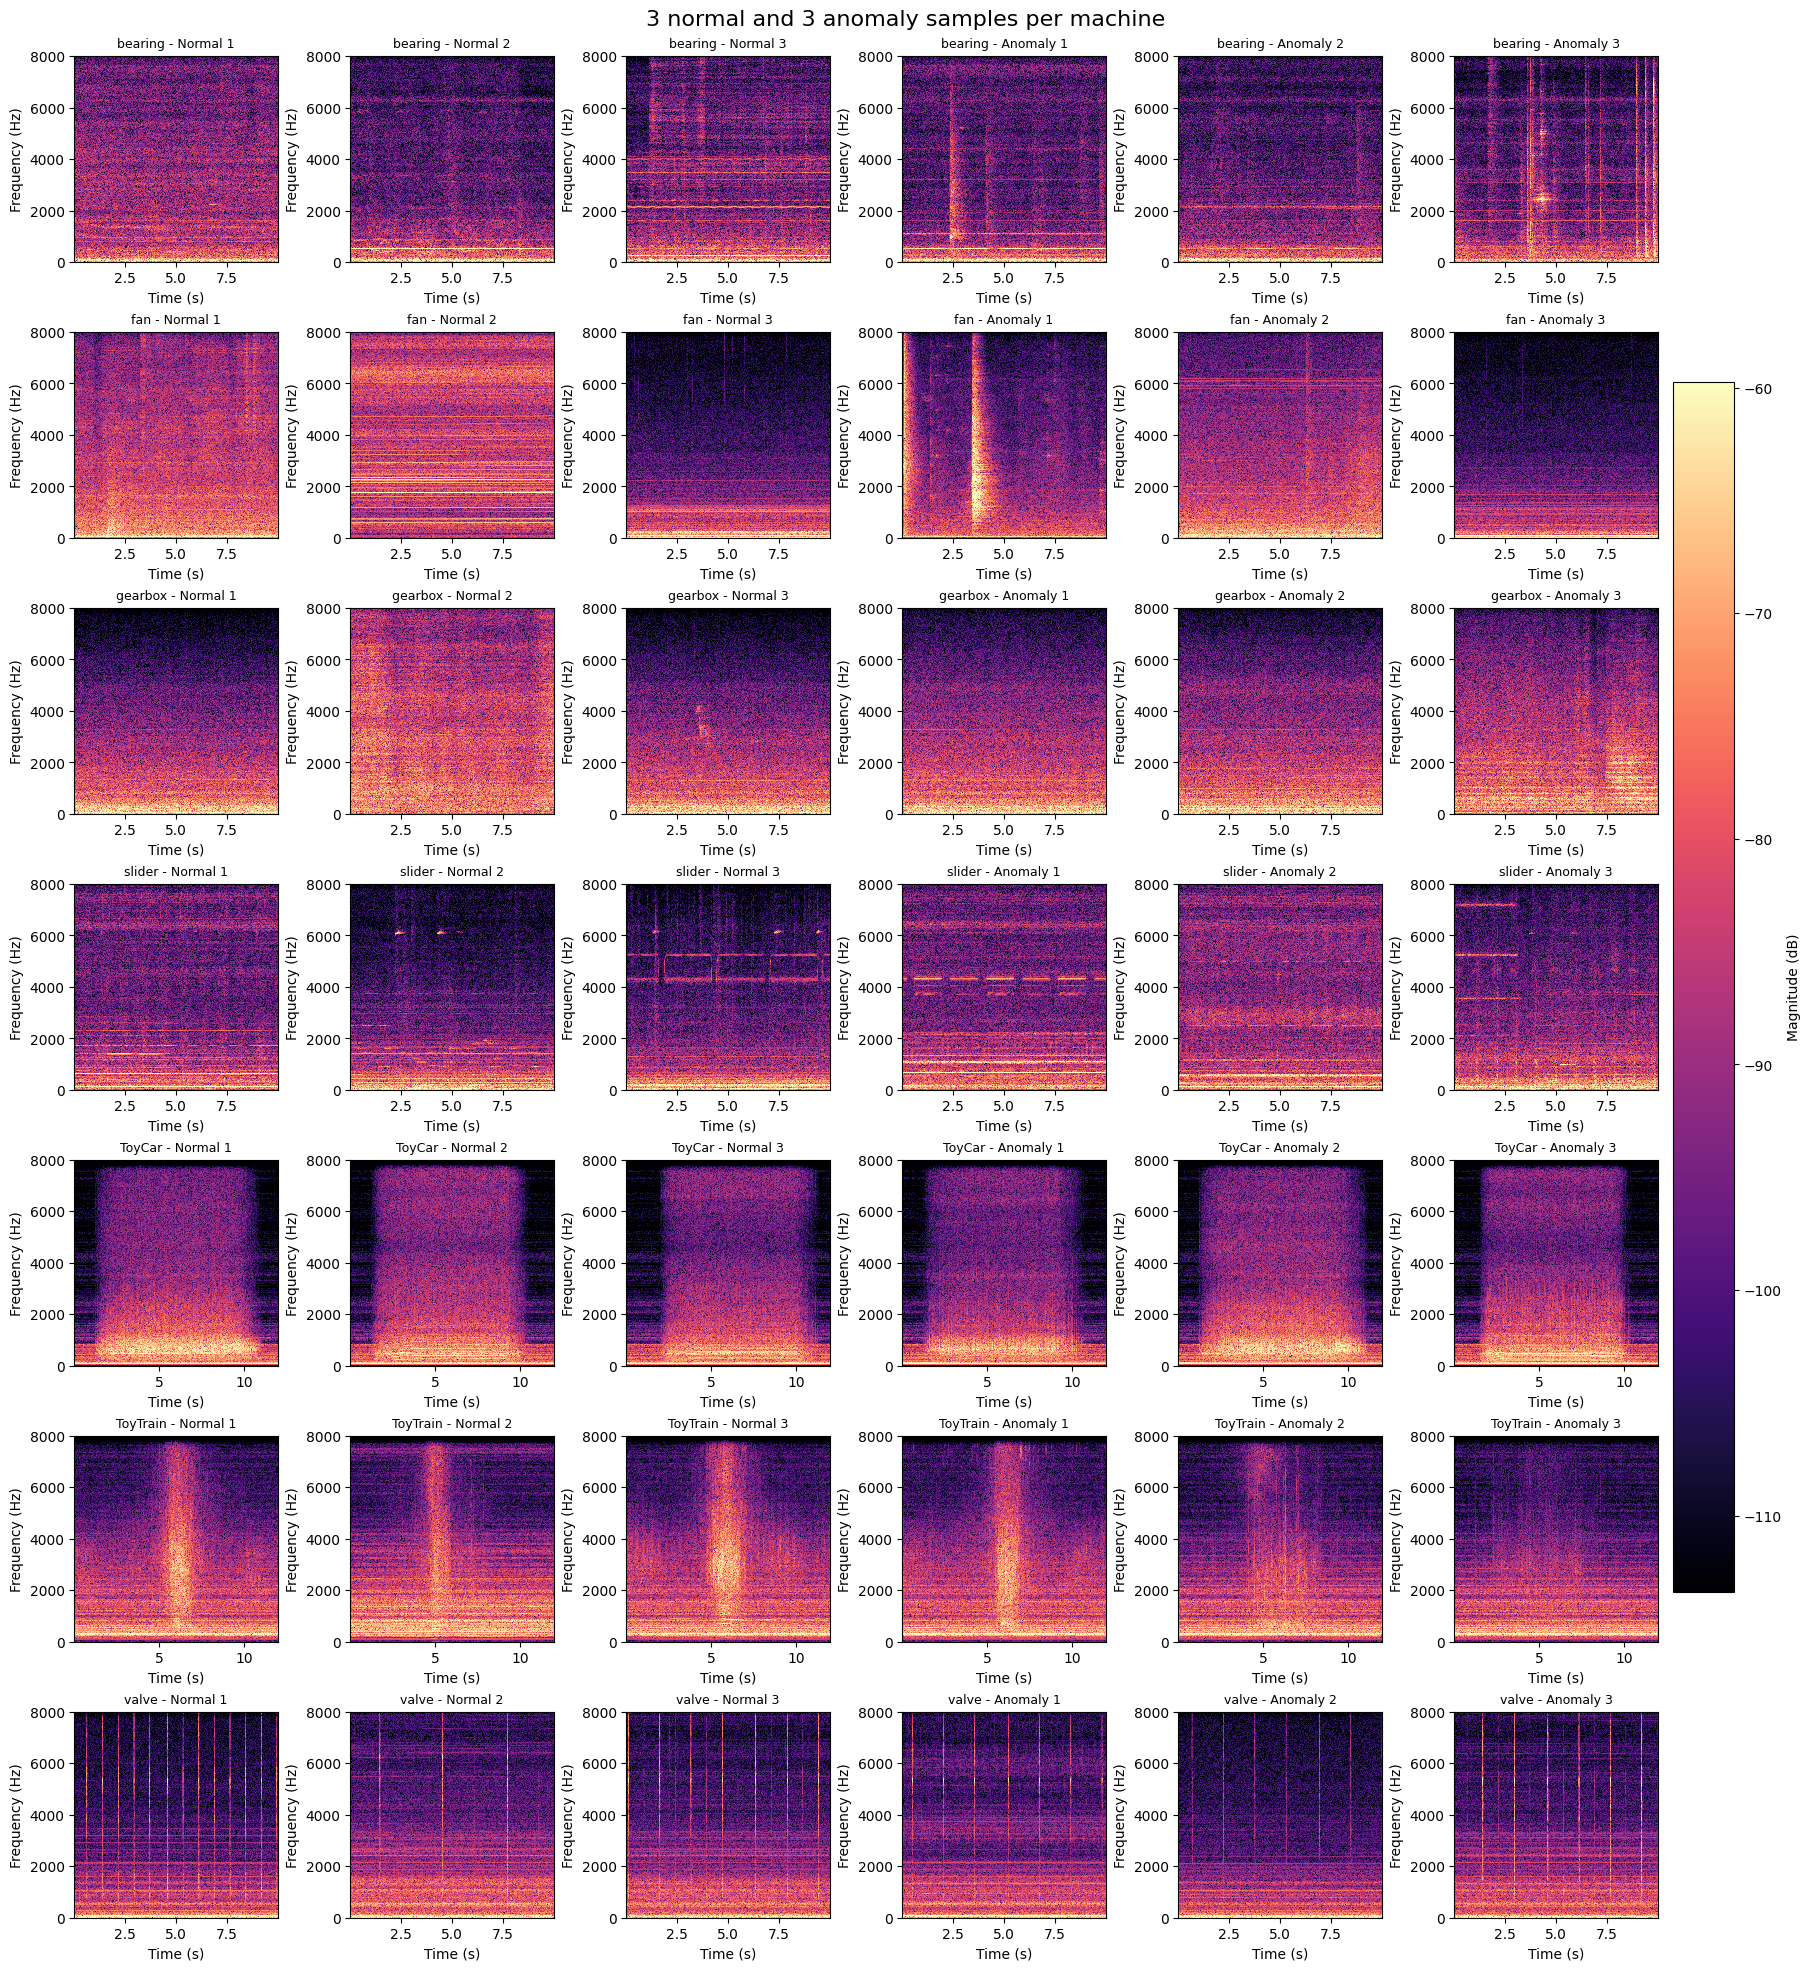

In [ ]:
# Spectrogram examples: one normal and one anomaly for each machine.
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
from scipy import signal
from scipy.io import wavfile

DATA_ROOT_FALLBACK = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
data_root = globals().get("DATA_ROOT", DATA_ROOT_FALLBACK)
machine_types = ["bearing", "fan", "gearbox", "slider", "ToyCar", "ToyTrain", "valve"]
SAMPLE_SELECTION_SEED = globals().get("SAMPLE_SELECTION_SEED", None)
sample_rng = np.random.default_rng(SAMPLE_SELECTION_SEED)


def _load_waveform_local(path, target_sr=16000):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0), target_sr


def _collect_machine_files_local(machine_type, split):
    split_dir = os.path.join(data_root, f"dev_{machine_type}", machine_type, split)
    return sorted(glob.glob(os.path.join(split_dir, "*.wav")))


def _pick_example(machine_type, split, keyword):
    candidates = [
        path
        for path in _collect_machine_files_local(machine_type, split)
        if keyword.lower() in os.path.basename(path).lower()
    ]
    return candidates[0] if candidates else None


def _collect_wav_examples(root_dir, keyword):
    if not os.path.isdir(root_dir):
        return []

    keyword = keyword.lower()
    matches = []
    for current_root, _, file_names in os.walk(root_dir):
        for file_name in sorted(file_names):
            if not file_name.lower().endswith(".wav"):
                continue
            full_path = os.path.join(current_root, file_name)
            path_text = full_path.replace('\\', '/').lower()
            if keyword in file_name.lower() or keyword in path_text:
                matches.append(full_path)
    return sorted(matches)


def _select_random_examples(paths, count=3, rng=None):
    if len(paths) <= count:
        return paths
    if rng is None:
        rng = np.random.default_rng()
    indices = rng.choice(len(paths), size=count, replace=False)
    return [paths[int(i)] for i in sorted(indices.tolist())]


def _compute_spectrogram_db(file_path):
    waveform, sample_rate = _load_waveform_local(file_path)
    waveform = waveform.numpy()
    waveform = waveform - waveform.mean()
    nperseg = min(1024, max(256, waveform.size // 4))
    noverlap = int(0.75 * nperseg)
    freqs, times, stft = signal.stft(
        waveform,
        fs=sample_rate,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        padded=False,
        boundary=None,
    )
    magnitude_db = 20.0 * np.log10(np.maximum(np.abs(stft), 1e-10))
    return freqs, times, magnitude_db, sample_rate


def _plot_spectrogram(ax, file_path, title, vmin=None, vmax=None):
    freqs, times, magnitude_db, sample_rate = _compute_spectrogram_db(file_path)
    if vmin is None:
        vmin = np.max(magnitude_db) - 80.0
    if vmax is None:
        vmax = np.max(magnitude_db)
    im = ax.pcolormesh(
        times,
        freqs,
        magnitude_db,
        shading="auto",
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_ylim(0.0, min(sample_rate / 2.0, 8000.0))
    return im


def _machine_db_limits(display_items, lower_pct=5.0, upper_pct=99.5, min_span_db=30.0, max_span_db=55.0):
    if len(display_items) == 0:
        return None, None

    machine_values = []
    for file_path, _ in display_items:
        _, _, magnitude_db, _ = _compute_spectrogram_db(file_path)
        machine_values.append(magnitude_db.reshape(-1))

    all_values = np.concatenate(machine_values, axis=0)
    vmin = float(np.percentile(all_values, lower_pct))
    vmax = float(np.percentile(all_values, upper_pct))

    if vmax <= vmin:
        vmax = float(np.max(all_values))
        vmin = float(np.min(all_values))

    span = vmax - vmin
    if span < min_span_db:
        center = 0.5 * (vmax + vmin)
        half = 0.5 * min_span_db
        vmin = center - half
        vmax = center + half
    elif span > max_span_db:
        vmin = vmax - max_span_db

    return vmin, vmax


machine_list = globals().get("machine_types", globals().get("ALL_MACHINE_TYPES", []))
root_dir = globals().get("data_root", globals().get("DATA_ROOT_FALLBACK", ""))

fig, axes = plt.subplots(
    len(machine_list),
    6,
    figsize=(18, 2.8 * len(machine_list)),
    constrained_layout=True,
)
if len(machine_list) == 1:
    axes = np.expand_dims(axes, axis=0)

last_im = None
for row_idx, machine in enumerate(machine_list):
    normal_root = os.path.join(root_dir, f"dev_{machine}", machine, "train")
    anomaly_root = os.path.join(root_dir, f"dev_{machine}", machine, "test")

    normal_paths = _select_random_examples(_collect_wav_examples(normal_root, "normal"), 3, rng=sample_rng)
    anomaly_paths = _select_random_examples(_collect_wav_examples(anomaly_root, "anomaly"), 3, rng=sample_rng)
    display_items = [(path, f"Normal {index + 1}") for index, path in enumerate(normal_paths)]
    display_items.extend((path, f"Anomaly {index + 1}") for index, path in enumerate(anomaly_paths))

    machine_min_db, machine_max_db = _machine_db_limits(display_items)

    for col_idx in range(6):
        ax = axes[row_idx, col_idx]
        if col_idx < len(display_items):
            file_path, label = display_items[col_idx]
            last_im = _plot_spectrogram(
                ax,
                file_path,
                f"{machine} - {label}",
                vmin=machine_min_db,
                vmax=machine_max_db,
            )
        else:
            ax.axis("off")
            ax.set_title(f"{machine} - example not found")

fig.suptitle("3 normal and 3 anomaly samples per machine", fontsize=16)
if last_im is not None:
    fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.65, pad=0.01, label="Magnitude (dB)")

plt.show()